In [1]:
!pip install audiomentations

INFO: pip is looking at multiple versions of numpy-minmax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of numpy-rms to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 3.7 MB/s eta 0:00:00


In [2]:


import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from audiomentations import Compose, AddGaussianNoise, PitchShift, TimeStretch, Shift, ClippingDistortion, PolarityInversion, Gain
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')



2025-04-30 22:07:17.801892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746050838.101098      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746050838.193517      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:


# Paths
DATA_PATH = '/kaggle/input/urbansound8k/'
METADATA_PATH = '/kaggle/input/urbansound8k/UrbanSound8K.csv'

# Metadata loading
metadata = pd.read_csv(METADATA_PATH)



In [4]:
def find_file(file_name, base_dir='/kaggle/input/urbansound8k/'):
    for folder in range(1, 11):
        file_path = os.path.join(base_dir, f"fold{folder}", file_name)
        if os.path.exists(file_path):
            return file_path
    return None

In [5]:


samples_to_consider = 22050 * 4



In [6]:
def extract_features(file_path, fixed_length=168, augment=False):
    augmenter = Compose([
        AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.02, p=0.5),
        PitchShift(min_semitones=-6, max_semitones=6, p=0.5),
        TimeStretch(min_rate=0.8, max_rate=1.2, p=0.4),
        Shift(min_shift=-0.7, max_shift=0.7, shift_unit='fraction', p=0.5),
        ClippingDistortion(p=0.3),
        PolarityInversion(p=0.3),
        Gain(min_gain_db=-6.0, max_gain_db=6.0, p=0.3),
    ])
    try:
        audio, sr = librosa.load(file_path, sr=22050, mono=True)
        mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=min(2048, len(audio)), n_mels=168, fmax=8000, hop_length=512)
        mel_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

        if augment and np.random.rand() < 0.5:
            num_freqs, num_frames = mel_db.shape
            f = np.random.randint(0, min(10, num_freqs))
            f0 = np.random.randint(0, num_freqs - f)
            mel_db[f0:f0 + f, :] = 0

            t = np.random.randint(0, min(20, num_frames))
            t0 = np.random.randint(0, num_frames - t)
            mel_db[:, t0:t0 + t] = 0

            audio = augmenter(samples=audio, sample_rate=sr)

        if mel_db.shape[1] > fixed_length:
            mel_db = mel_db[:, :fixed_length]
        else:
            mel_db = np.pad(mel_db, ((0, 0), (0, fixed_length - mel_db.shape[1])), mode='constant')
        return mel_db
    except Exception as e:
        print(f"❌ Error processing {file_path}: {e}")
        return None

In [7]:
X, y = [], []
for index, row in tqdm(metadata.iterrows(), total=len(metadata)):
    file_path = find_file(row['slice_file_name'], DATA_PATH)
    if os.path.exists(file_path):
        features = extract_features(file_path, augment=np.random.rand() < 0.5)
        if features is not None:
            X.append(features)
            y.append(row['classID'])

100%|██████████| 8732/8732 [07:54<00:00, 18.39it/s]



🔊 Class: dog_bark
🎚 Pitch Shift: -3 semitones


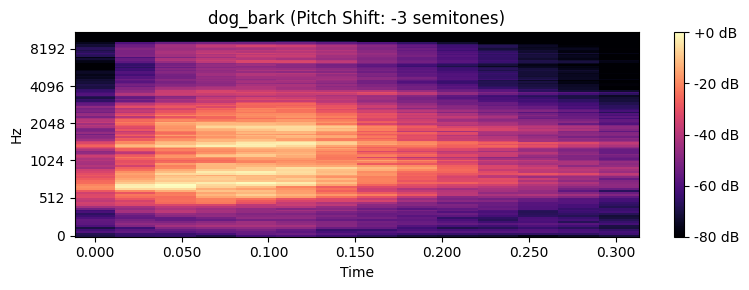


🔊 Class: children_playing
🎚 Pitch Shift: -2 semitones


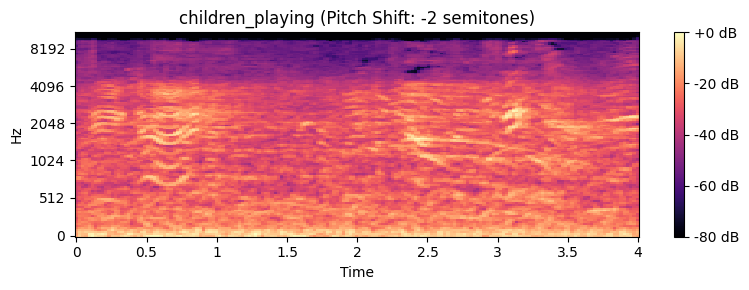


🔊 Class: car_horn
🎚 Pitch Shift: +0 semitones


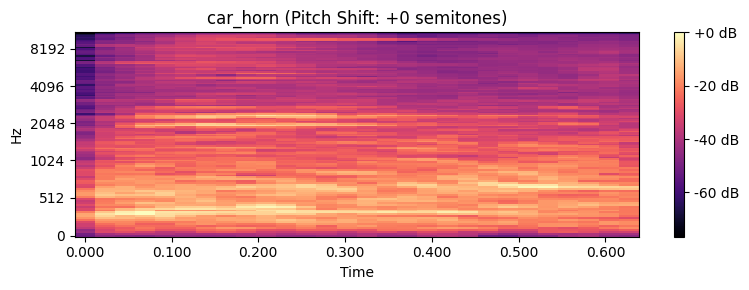


🔊 Class: air_conditioner
🎚 Pitch Shift: +2 semitones


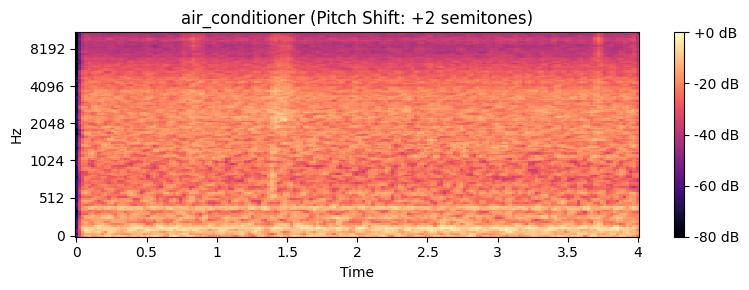


🔊 Class: street_music
🎚 Pitch Shift: +3 semitones


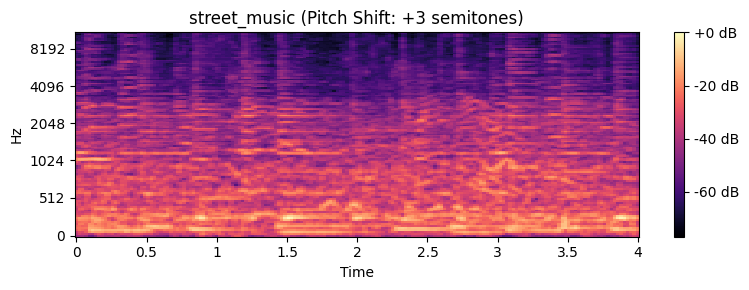


🔊 Class: gun_shot
🎚 Pitch Shift: +4 semitones


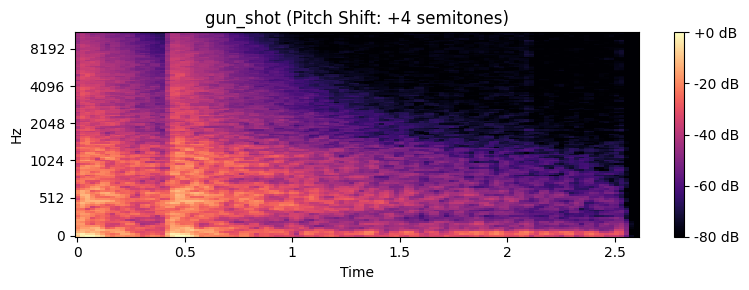


🔊 Class: siren
🎚 Pitch Shift: +5 semitones


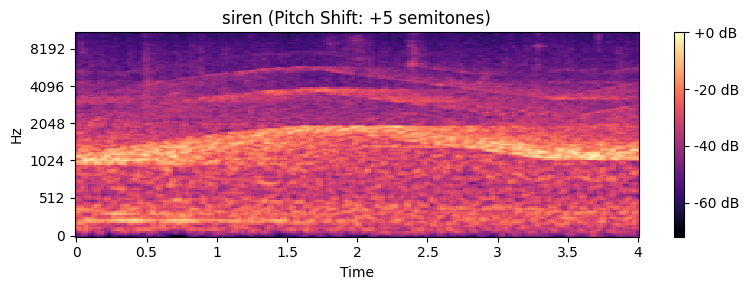


🔊 Class: engine_idling
🎚 Pitch Shift: +6 semitones


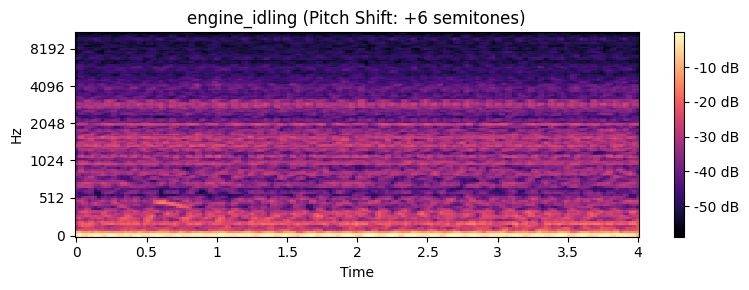


🔊 Class: jackhammer
🎚 Pitch Shift: -3 semitones


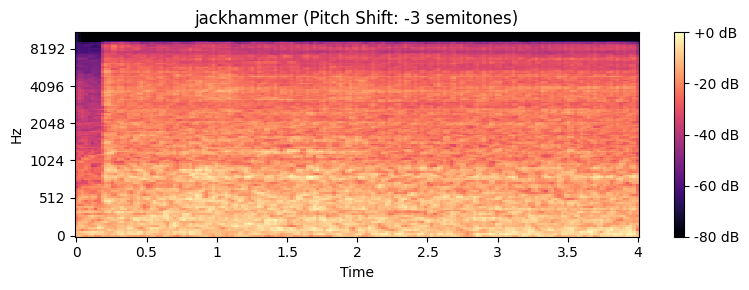


🔊 Class: drilling
🎚 Pitch Shift: -2 semitones


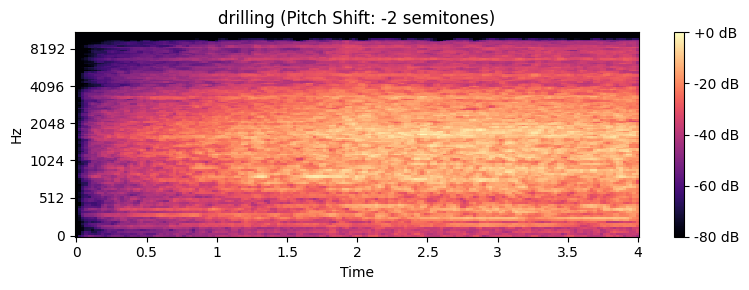

In [8]:
from audiomentations import PitchShift
import IPython.display as ipd
import random

# Unique pitch shifts to assign randomly
pitch_shifts = [-3, -2, 0, 2, 3, 4, 5, 6]

# Get unique class names
class_labels = metadata['class'].unique()

for i, label in enumerate(class_labels):
    print(f"\n🔊 Class: {label}")

    # Select first sample for each class
    row = metadata[metadata['class'] == label].iloc[0]
    file_path = find_file(row['slice_file_name'], DATA_PATH)

    # Load audio
    audio, sr = librosa.load(file_path, sr=22050)

    # Select a different pitch for each class
    semitone = pitch_shifts[i % len(pitch_shifts)]
    augmenter = PitchShift(min_semitones=semitone, max_semitones=semitone, p=1.0)
    shifted_audio = augmenter(samples=audio, sample_rate=sr)

    # Display pitch and audio
    print(f"🎚 Pitch Shift: {semitone:+} semitones")
    ipd.display(ipd.Audio(shifted_audio, rate=sr))

    # Plot Mel spectrogram
    mel_spec = librosa.feature.melspectrogram(y=shifted_audio, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    plt.figure(figsize=(8, 3))
    librosa.display.specshow(mel_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{label} (Pitch Shift: {semitone:+} semitones)")
    plt.tight_layout()
    plt.show()


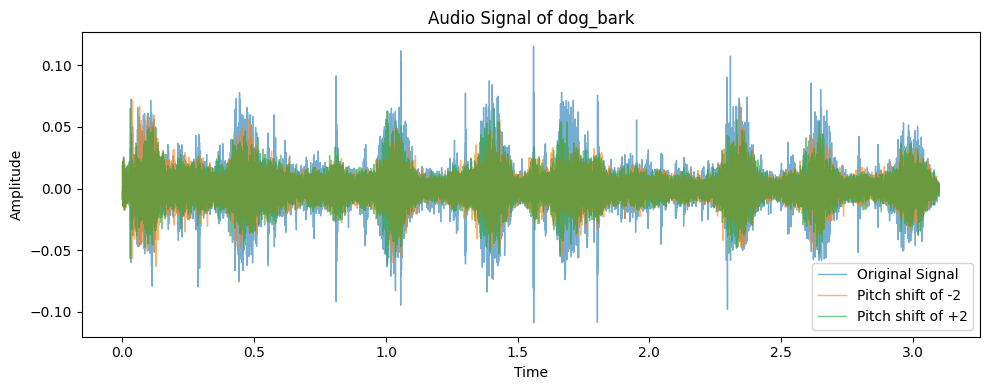

In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Select any row from the metadata
sample_row = metadata.iloc[100]  # change the index to select another sample
file_name = sample_row['slice_file_name']
label_name = sample_row['class']
file_path = find_file(file_name, DATA_PATH)

# Load audio
audio, sr = librosa.load(file_path, sr=22050)

# Apply pitch shifts
pitch_shift_minus2 = librosa.effects.pitch_shift(audio, sr=sr, n_steps=-2)
pitch_shift_plus2 = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)

# Time axis
time = np.linspace(0, len(audio) / sr, len(audio))

# Plot
plt.figure(figsize=(10, 4))
plt.plot(time, audio, label='Original Signal', alpha=0.6, linewidth=1)
plt.plot(time, pitch_shift_minus2, label='Pitch shift of -2', alpha=0.6, linewidth=1)
plt.plot(time, pitch_shift_plus2, label='Pitch shift of +2', alpha=0.6, linewidth=1)
plt.title(f'Audio Signal of {label_name}')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
import os

# Directory to save plots
os.makedirs("pitch_shift_plots", exist_ok=True)

# Unique class labels
unique_classes = metadata['class'].unique()

# Plot for each class
for sound_class in unique_classes:
    class_rows = metadata[metadata['class'] == sound_class]
    sample_row = class_rows.sample(n=1).iloc[0]

    file_name = sample_row['slice_file_name']
    file_path = find_file(file_name, DATA_PATH)
    if not file_path:
        continue

    audio, sr = librosa.load(file_path, sr=22050)
    pitch_shift_minus2 = librosa.effects.pitch_shift(audio, sr=sr, n_steps=-2)
    pitch_shift_plus2 = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
    time = np.linspace(0, len(audio)/sr, len(audio))

    plt.figure(figsize=(10, 4))
    plt.plot(time, audio, label='Original Signal', alpha=0.6, linewidth=1)
    plt.plot(time, pitch_shift_minus2, label='Pitch shift of -2', alpha=0.6, linewidth=1)
    plt.plot(time, pitch_shift_plus2, label='Pitch shift of +2', alpha=0.6, linewidth=1)
    plt.title(f'Audio Signal of {sound_class}')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.tight_layout()

    # Save the plot
    filename = f"pitch_shift_plots/{sound_class.replace(' ', '_')}.png"
    plt.savefig(filename)
    plt.close()


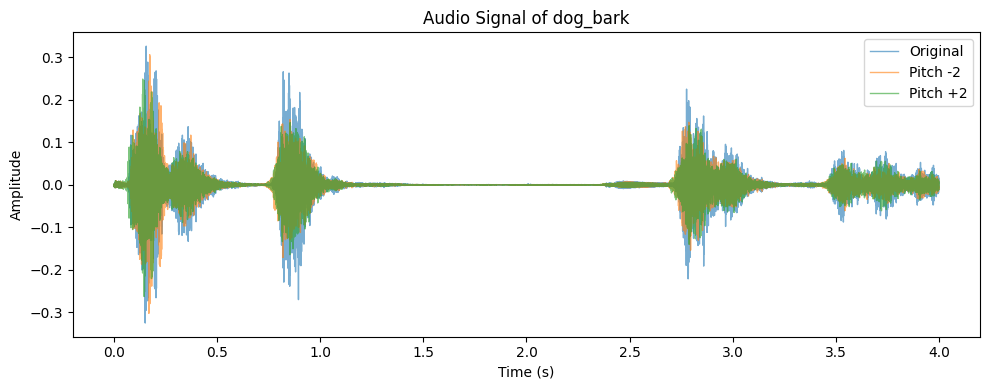

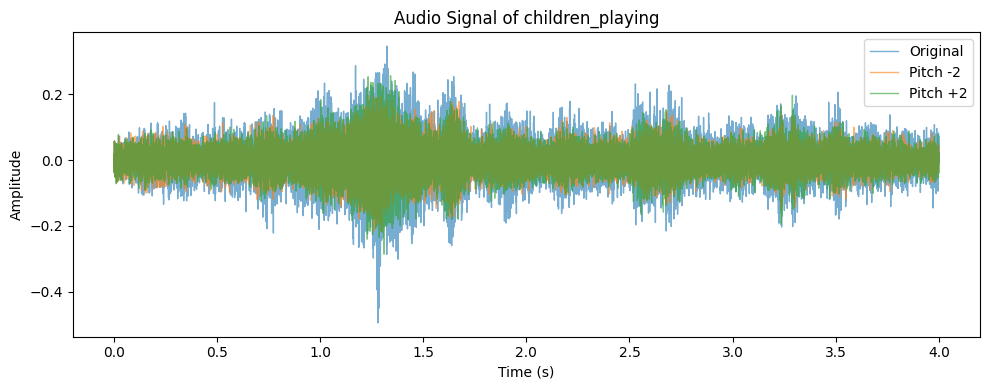

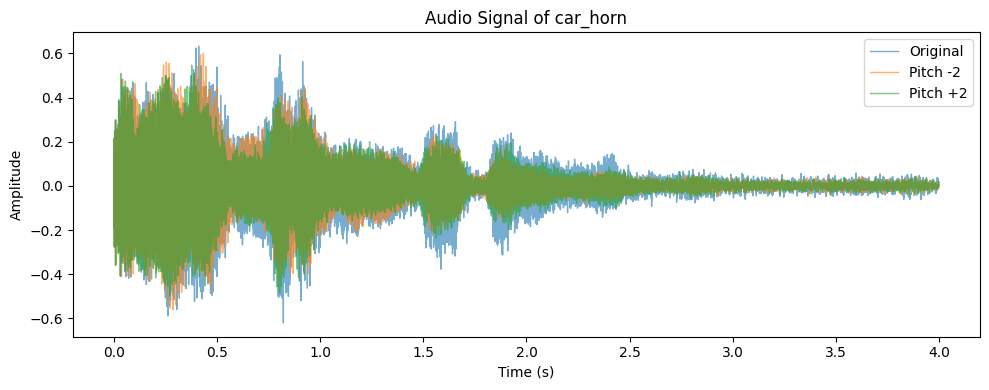

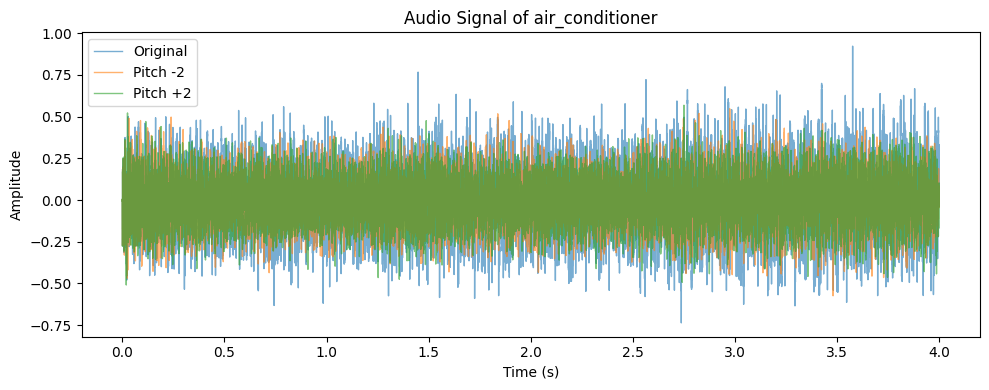

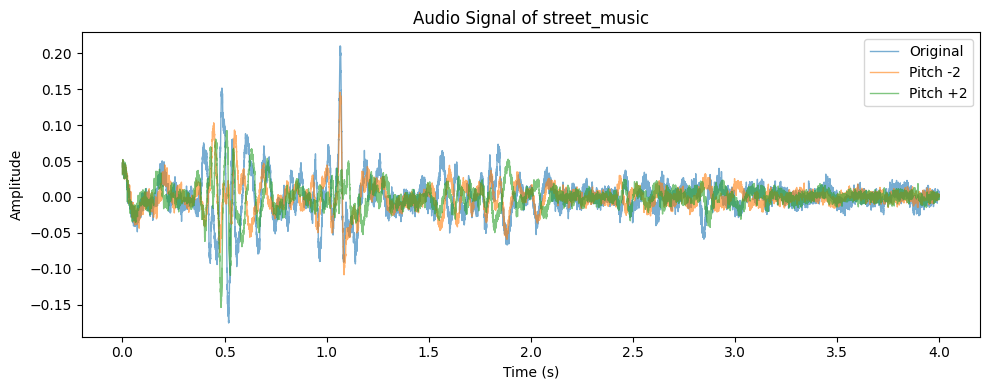

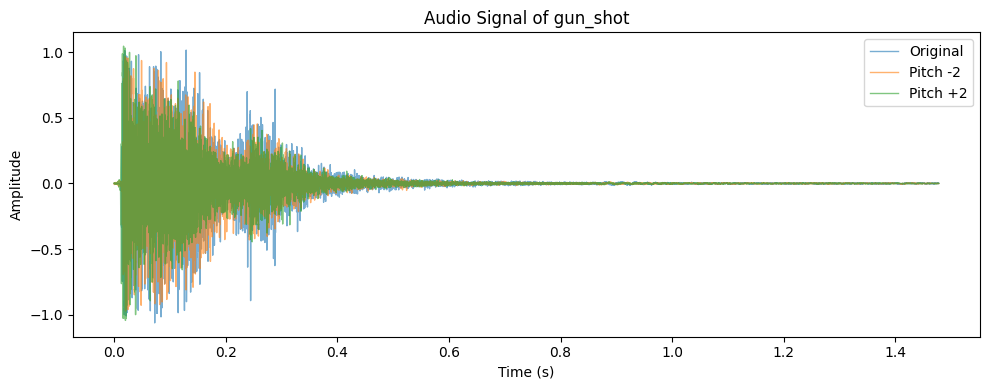

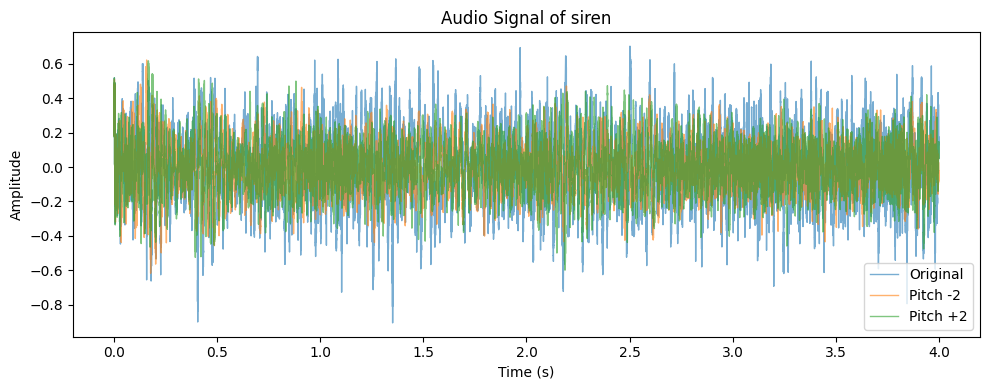

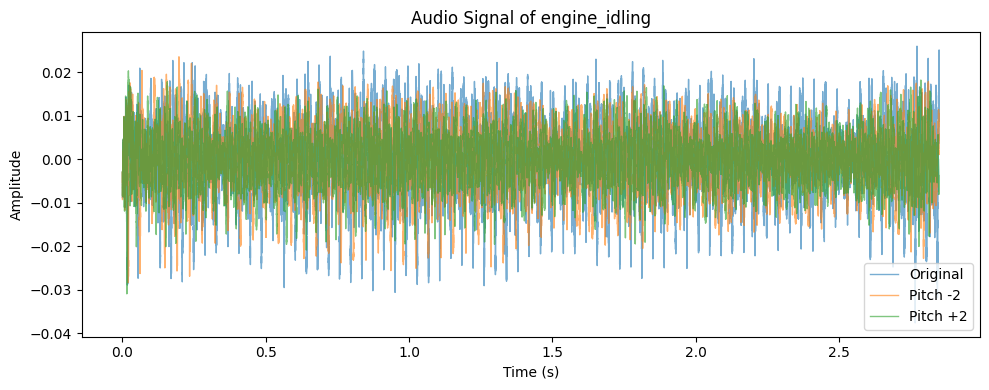

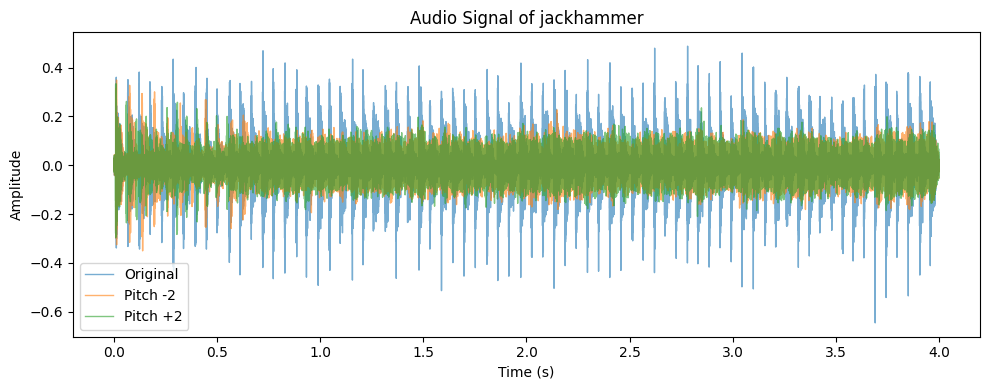

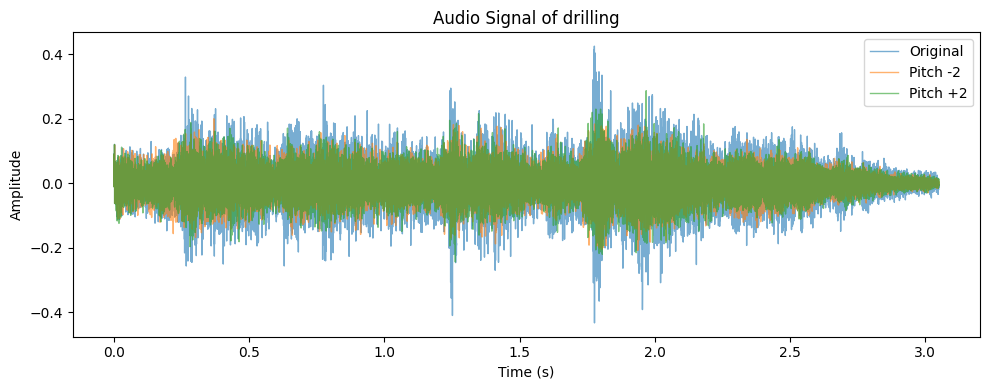

In [11]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

# Get all unique class labels
unique_classes = metadata['class'].unique()

# Plot for each class (dog_bark, etc.)
for sound_class in unique_classes:
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)
    
    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    # Load and pitch shift
    audio, sr = librosa.load(file_path, sr=22050)
    pitch_minus2 = librosa.effects.pitch_shift(audio, sr=sr, n_steps=-2)
    pitch_plus2 = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
    time = np.linspace(0, len(audio)/sr, len(audio))

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(time, audio, label='Original', alpha=0.6, linewidth=1)
    plt.plot(time, pitch_minus2, label='Pitch -2', alpha=0.6, linewidth=1)
    plt.plot(time, pitch_plus2, label='Pitch +2', alpha=0.6, linewidth=1)
    plt.title(f'Audio Signal of {sound_class}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()


<h1>Audio signal after time stretch</h1>

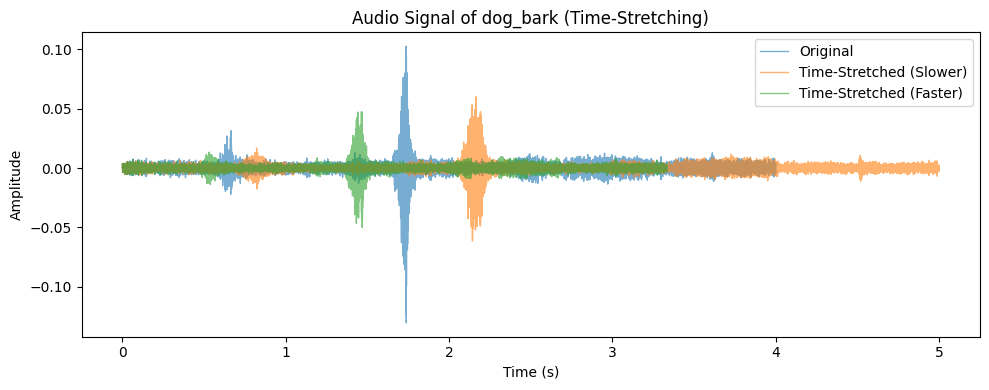

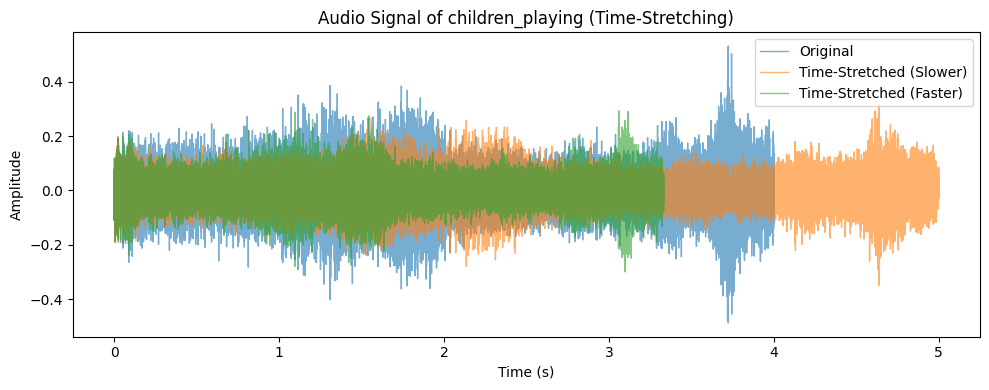

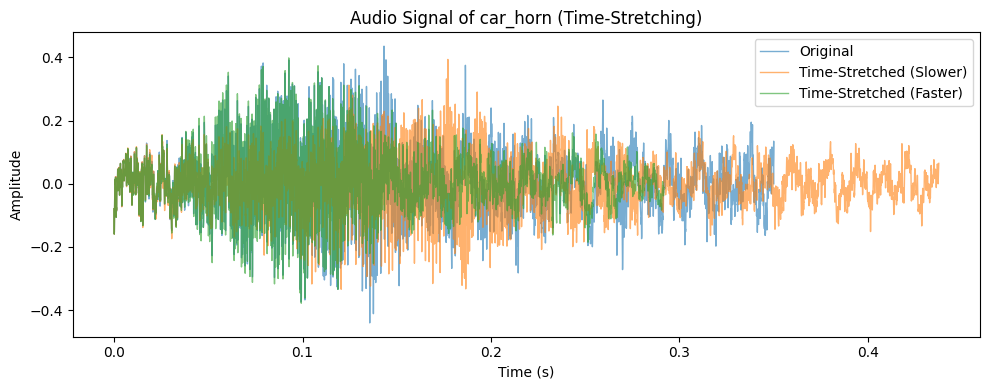

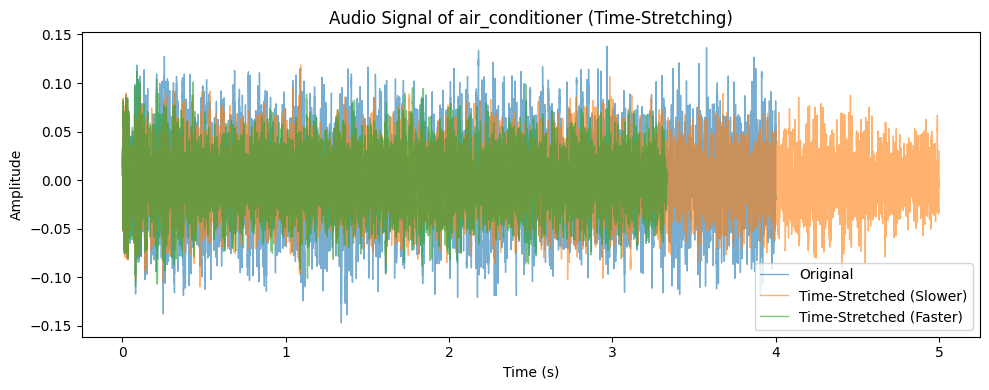

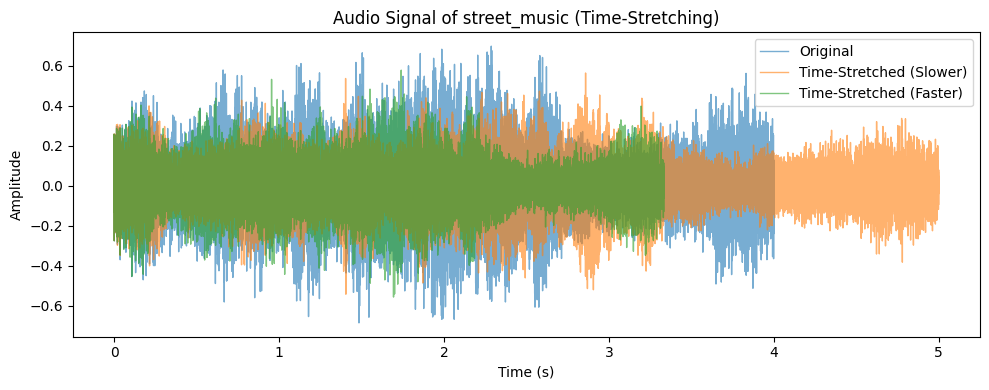

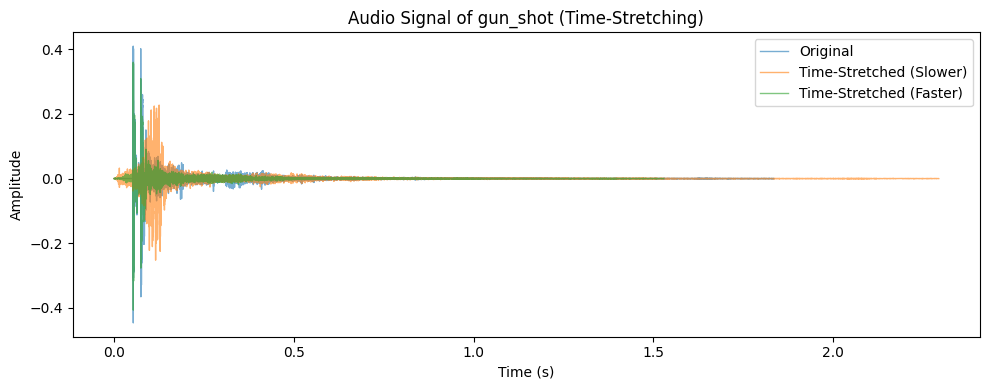

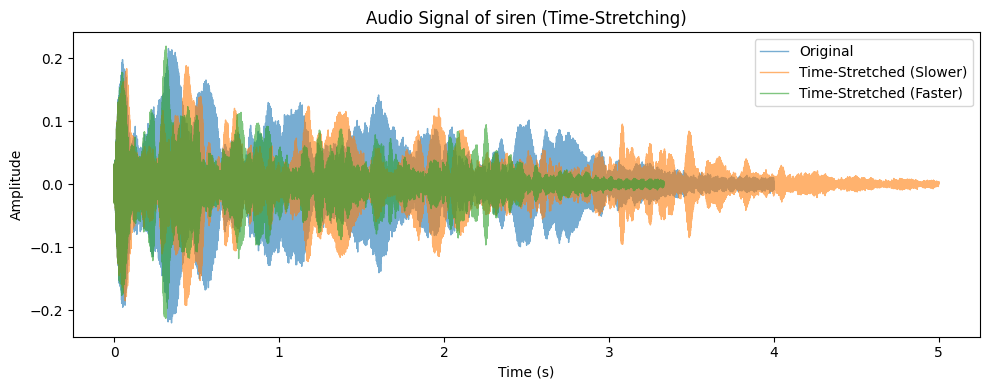

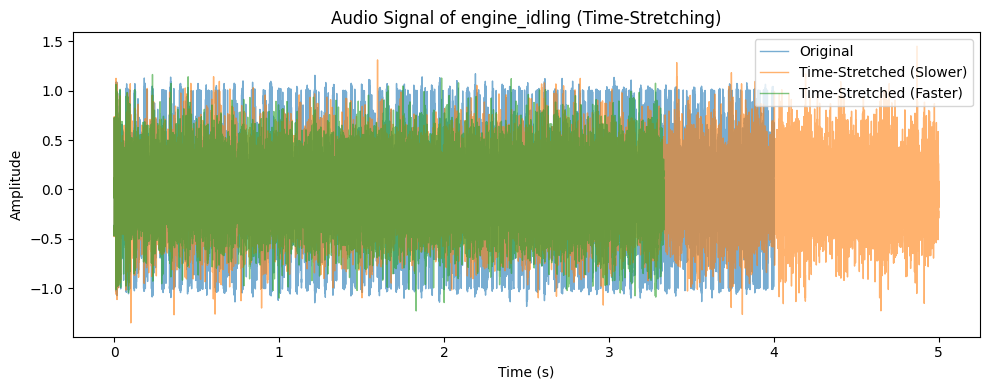

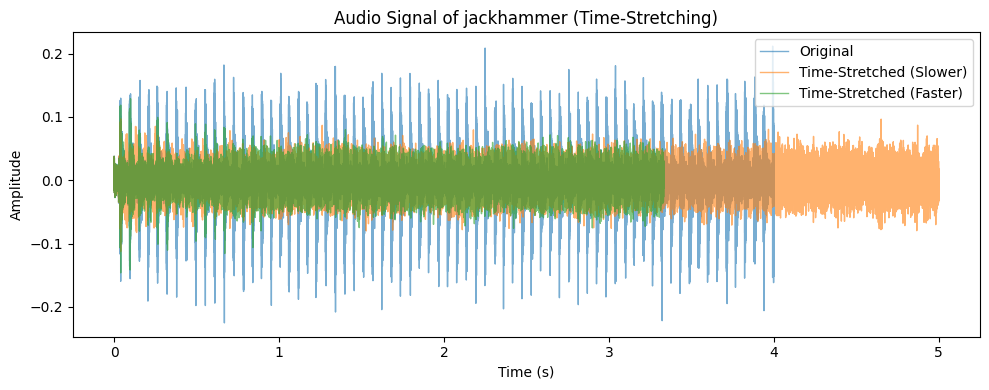

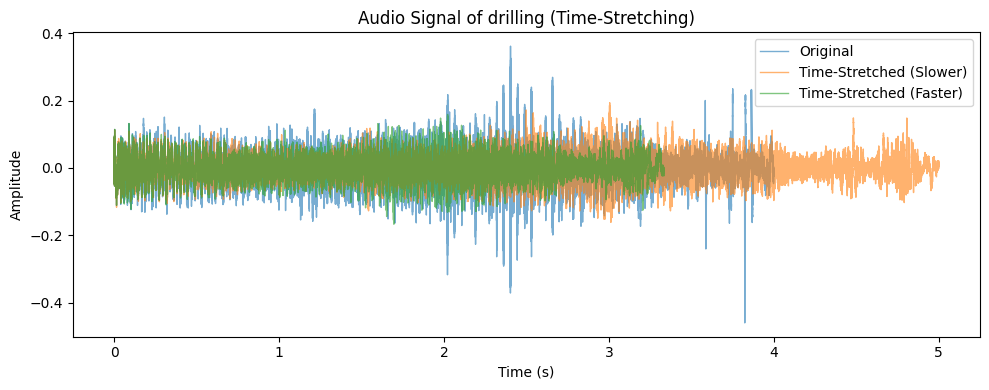

In [12]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

# Unique classes from metadata
unique_classes = metadata['class'].unique()

# Plot waveforms for each class with time-stretching
for sound_class in unique_classes:
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)
    
    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    # Load audio
    audio, sr = librosa.load(file_path, sr=22050)

    # Apply time-stretching
    stretch_slow = librosa.effects.time_stretch(audio, rate=0.8)  # Slower
    stretch_fast = librosa.effects.time_stretch(audio, rate=1.2)  # Faster

    # Generate time axes
    time_orig = np.linspace(0, len(audio)/sr, len(audio))
    time_slow = np.linspace(0, len(stretch_slow)/sr, len(stretch_slow))
    time_fast = np.linspace(0, len(stretch_fast)/sr, len(stretch_fast))

    # Plot waveforms
    plt.figure(figsize=(10, 4))
    plt.plot(time_orig, audio, label='Original', alpha=0.6, linewidth=1)
    plt.plot(time_slow, stretch_slow, label='Time-Stretched (Slower)', alpha=0.6, linewidth=1)
    plt.plot(time_fast, stretch_fast, label='Time-Stretched (Faster)', alpha=0.6, linewidth=1)
    plt.title(f'Audio Signal of {sound_class} (Time-Stretching)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()


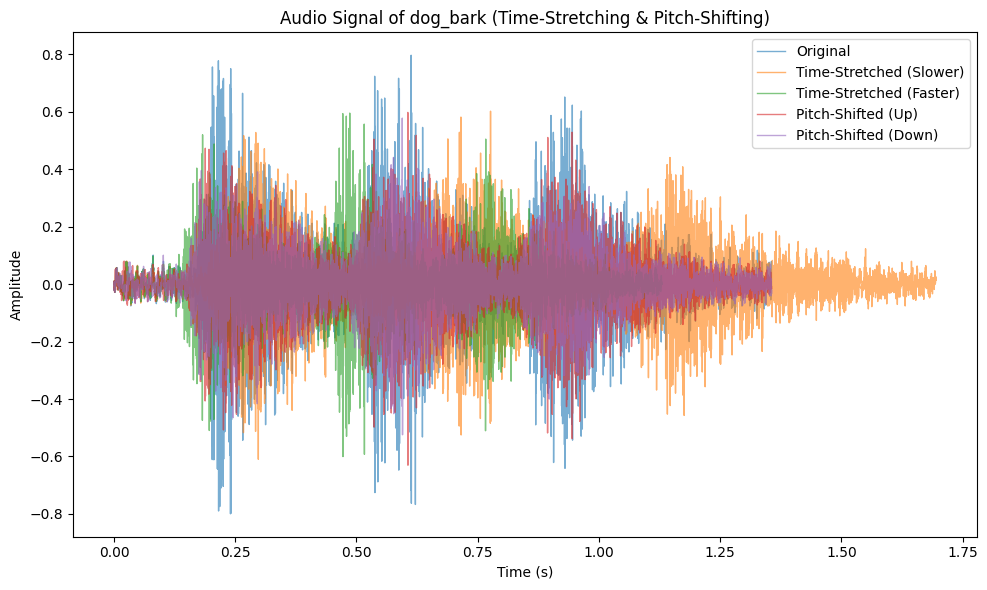

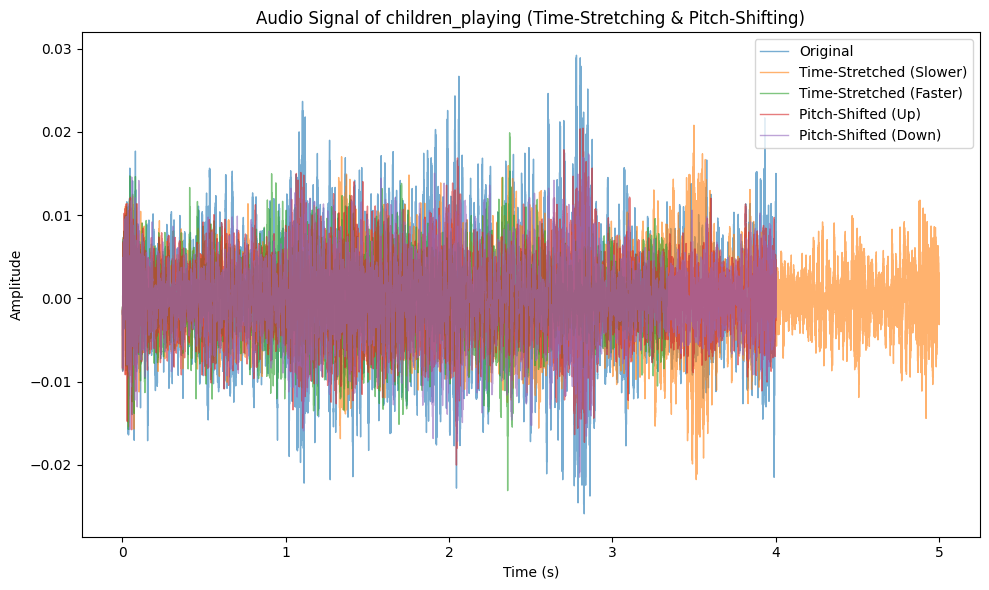

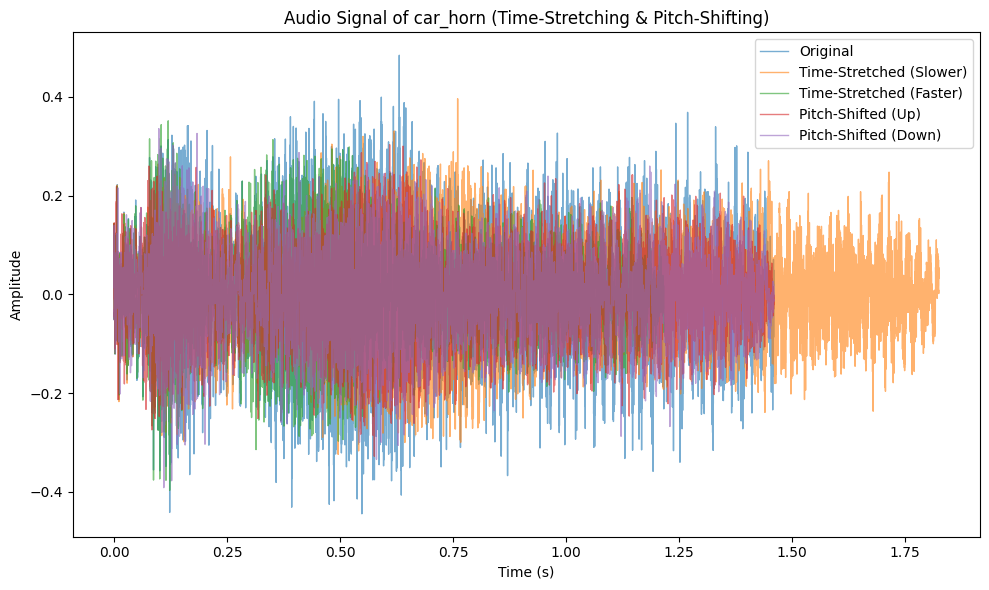

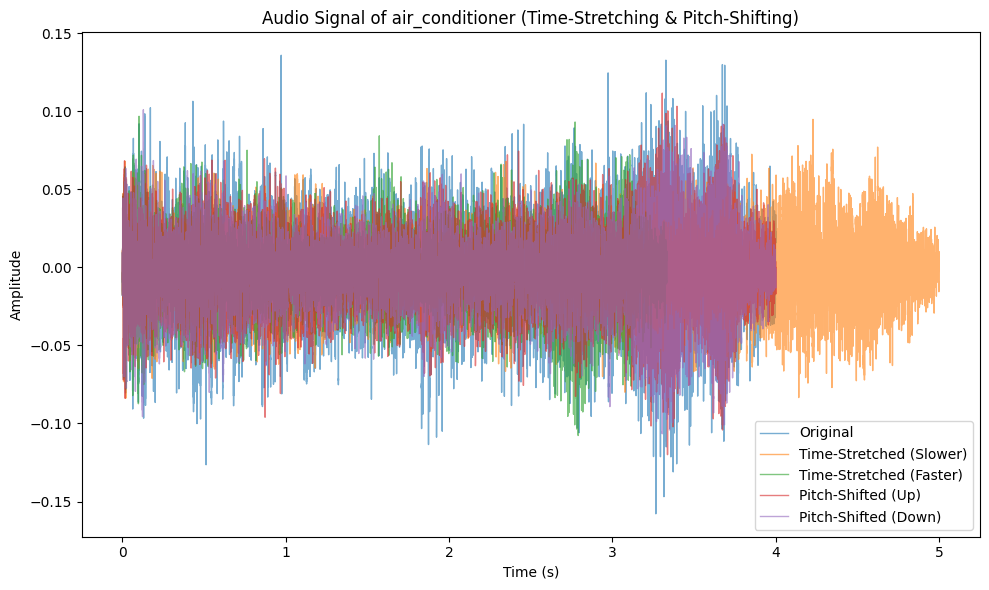

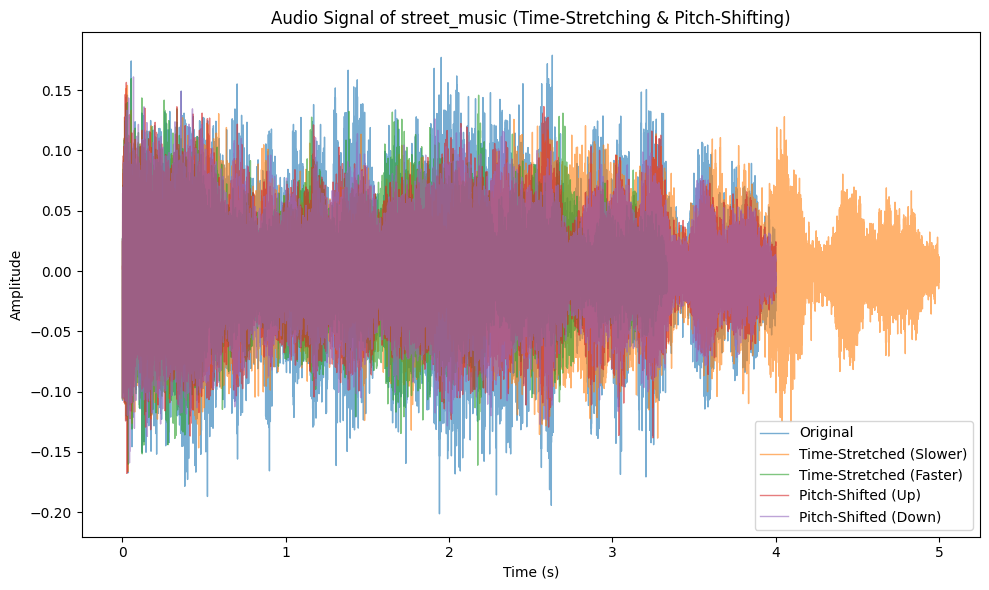

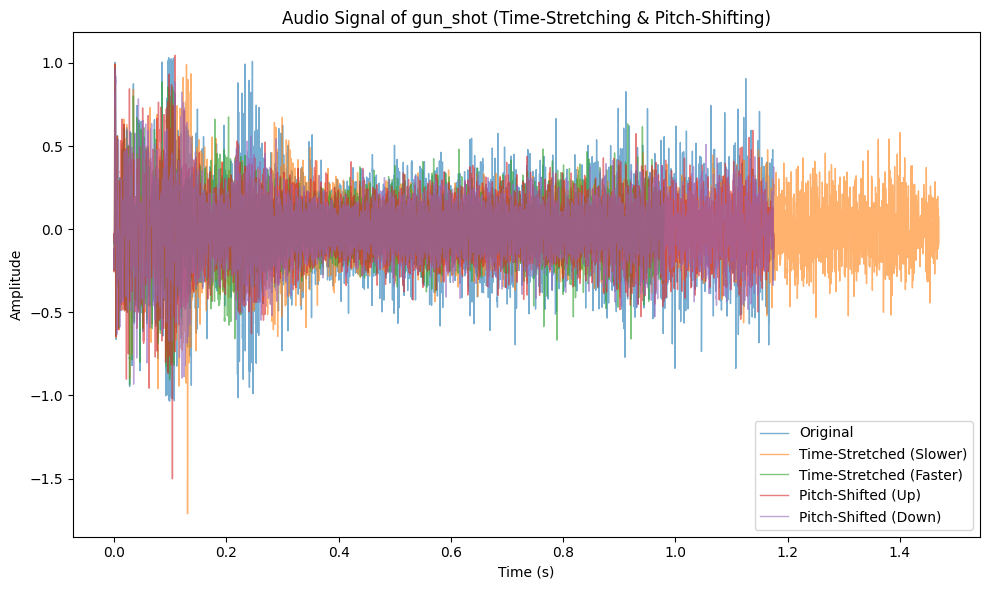

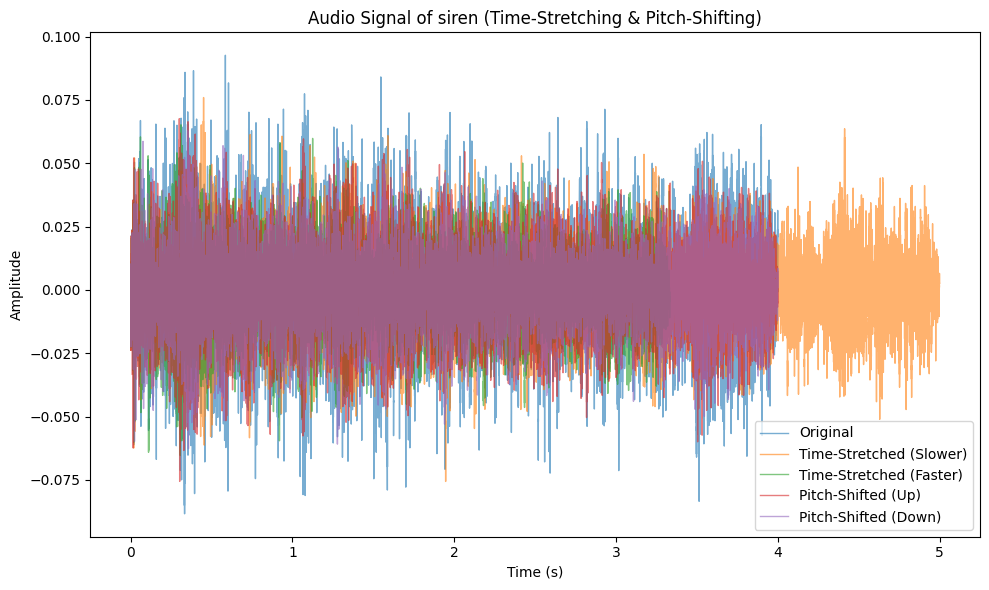

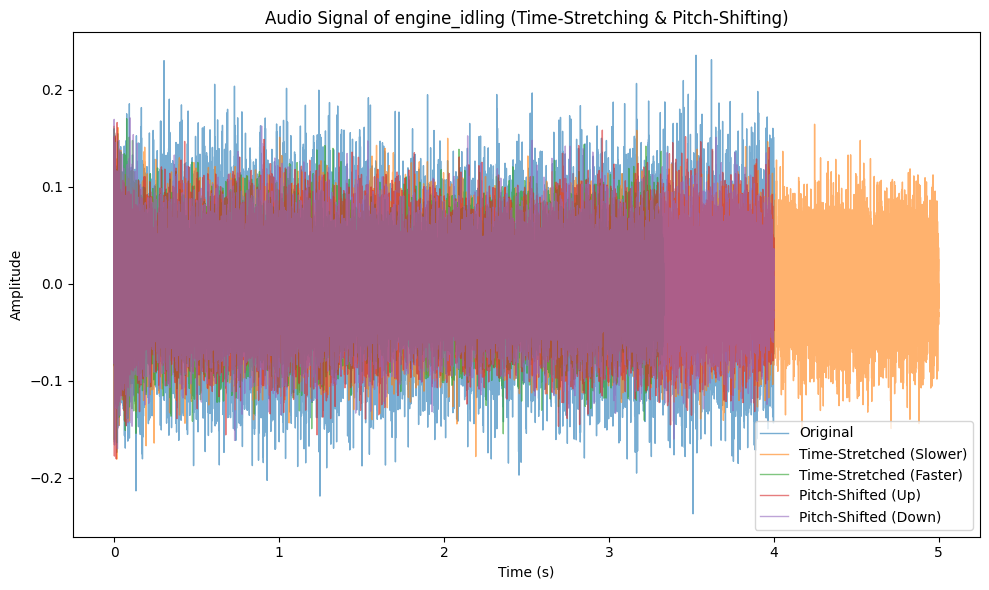

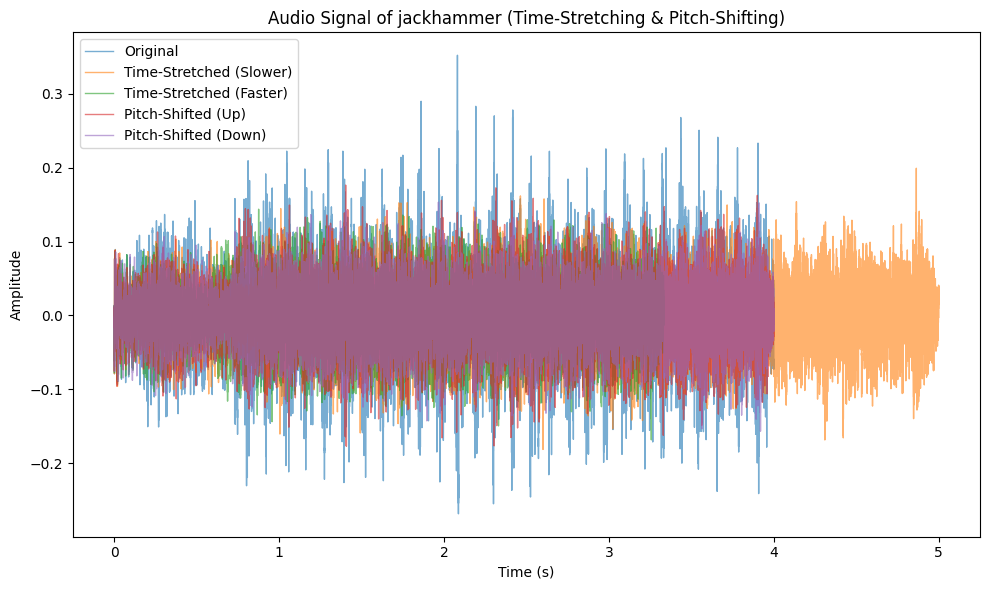

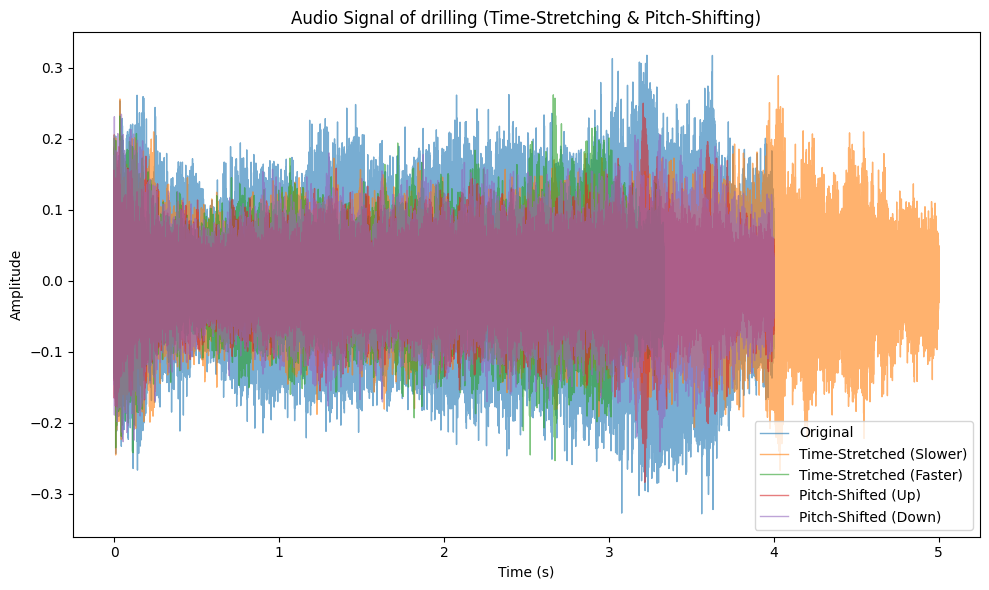

In [13]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

# Unique classes from metadata
unique_classes = metadata['class'].unique()

# Plot waveforms for each class with time-stretching and pitch-shifting
for sound_class in unique_classes:
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)
    
    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    # Load audio
    audio, sr = librosa.load(file_path, sr=22050)

    # Apply time-stretching
    stretch_slow = librosa.effects.time_stretch(audio, rate=0.8)  # Slower
    stretch_fast = librosa.effects.time_stretch(audio, rate=1.2)  # Faster

    # Apply pitch-shifting
    pitch_shift_up = librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=4)  # Shift pitch up by 4 semitones
    pitch_shift_down = librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=-4)  # Shift pitch down by 4 semitones

    # Generate time axes
    time_orig = np.linspace(0, len(audio)/sr, len(audio))
    time_slow = np.linspace(0, len(stretch_slow)/sr, len(stretch_slow))
    time_fast = np.linspace(0, len(stretch_fast)/sr, len(stretch_fast))
    time_pitch_up = np.linspace(0, len(pitch_shift_up)/sr, len(pitch_shift_up))
    time_pitch_down = np.linspace(0, len(pitch_shift_down)/sr, len(pitch_shift_down))

    # Plot waveforms
    plt.figure(figsize=(10, 6))
    plt.plot(time_orig, audio, label='Original', alpha=0.6, linewidth=1)
    plt.plot(time_slow, stretch_slow, label='Time-Stretched (Slower)', alpha=0.6, linewidth=1)
    plt.plot(time_fast, stretch_fast, label='Time-Stretched (Faster)', alpha=0.6, linewidth=1)
    plt.plot(time_pitch_up, pitch_shift_up, label='Pitch-Shifted (Up)', alpha=0.6, linewidth=1)
    plt.plot(time_pitch_down, pitch_shift_down, label='Pitch-Shifted (Down)', alpha=0.6, linewidth=1)
    
    plt.title(f'Audio Signal of {sound_class} (Time-Stretching & Pitch-Shifting)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()


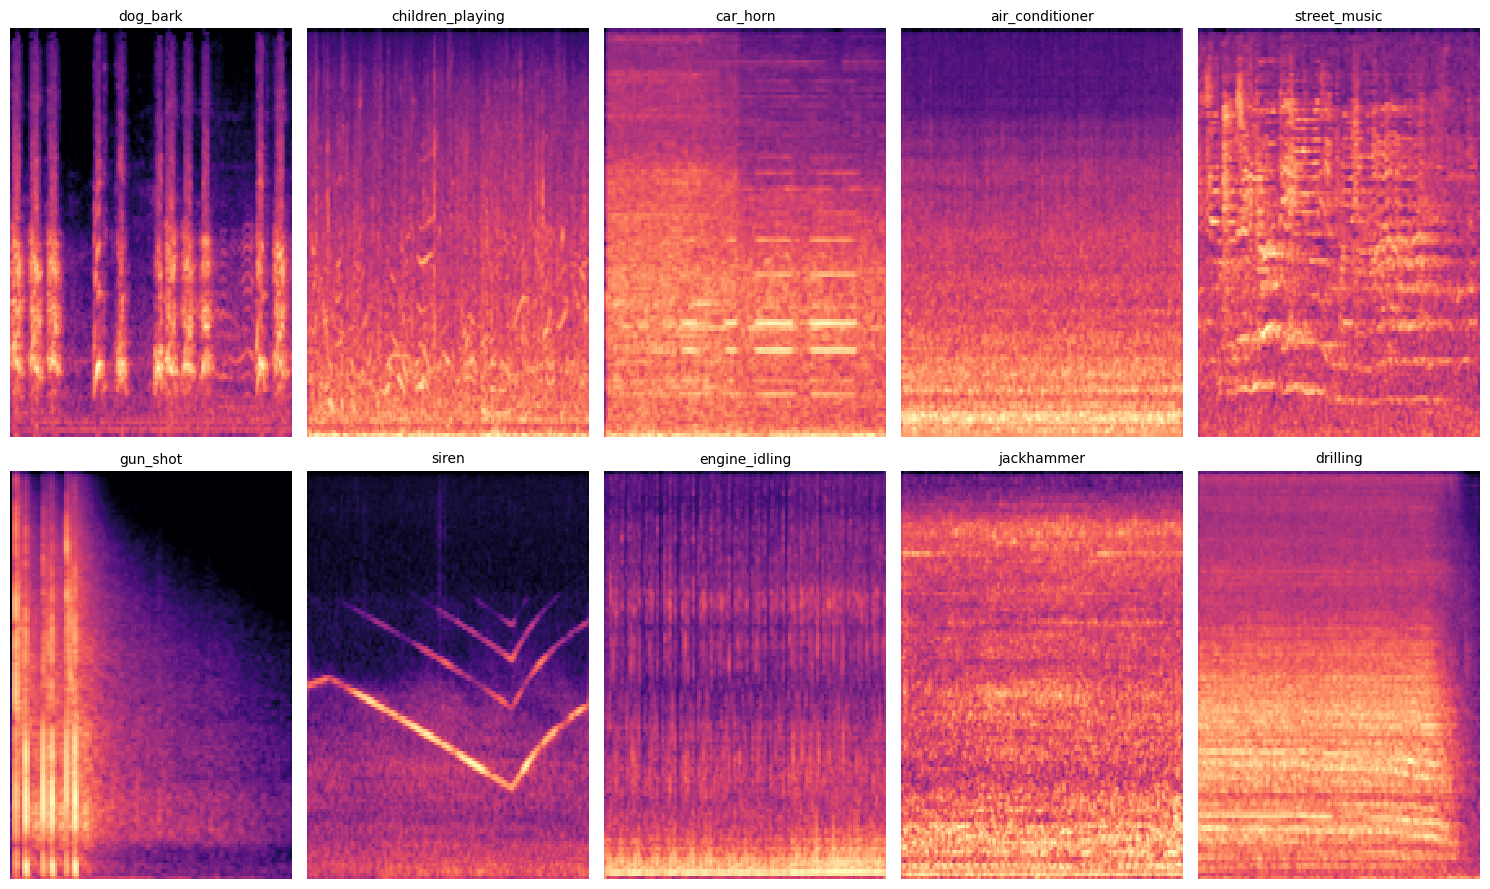

In [14]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output directory if it doesn't exist
output_dir = "/kaggle/working/spectrograms"
os.makedirs(output_dir, exist_ok=True)

# Unique classes from metadata
unique_classes = metadata['class'].unique()

# Set up plot grid (e.g., 3 rows x 5 columns if 15 classes)
n_classes = len(unique_classes)
cols = 5
rows = int(np.ceil(n_classes / cols))
plt.figure(figsize=(15, 9))  # Adjust based on how many classes you have

for i, sound_class in enumerate(unique_classes):
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)

    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    # Load audio
    audio, sr = librosa.load(file_path, sr=22050)

    # Generate mel spectrogram and convert to dB
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Plot in grid
    plt.subplot(rows, cols, i + 1)
    librosa.display.specshow(mel_db, sr=sr, cmap='magma')
    plt.axis('off')
    plt.title(sound_class, fontsize=10)

    # Save individual image
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    librosa.display.specshow(mel_db, sr=sr, cmap='magma', ax=ax)
    ax.axis('off')
    plt.tight_layout(pad=0)
    save_path = os.path.join(output_dir, f"{sound_class}.png")
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

plt.tight_layout()
plt.show()


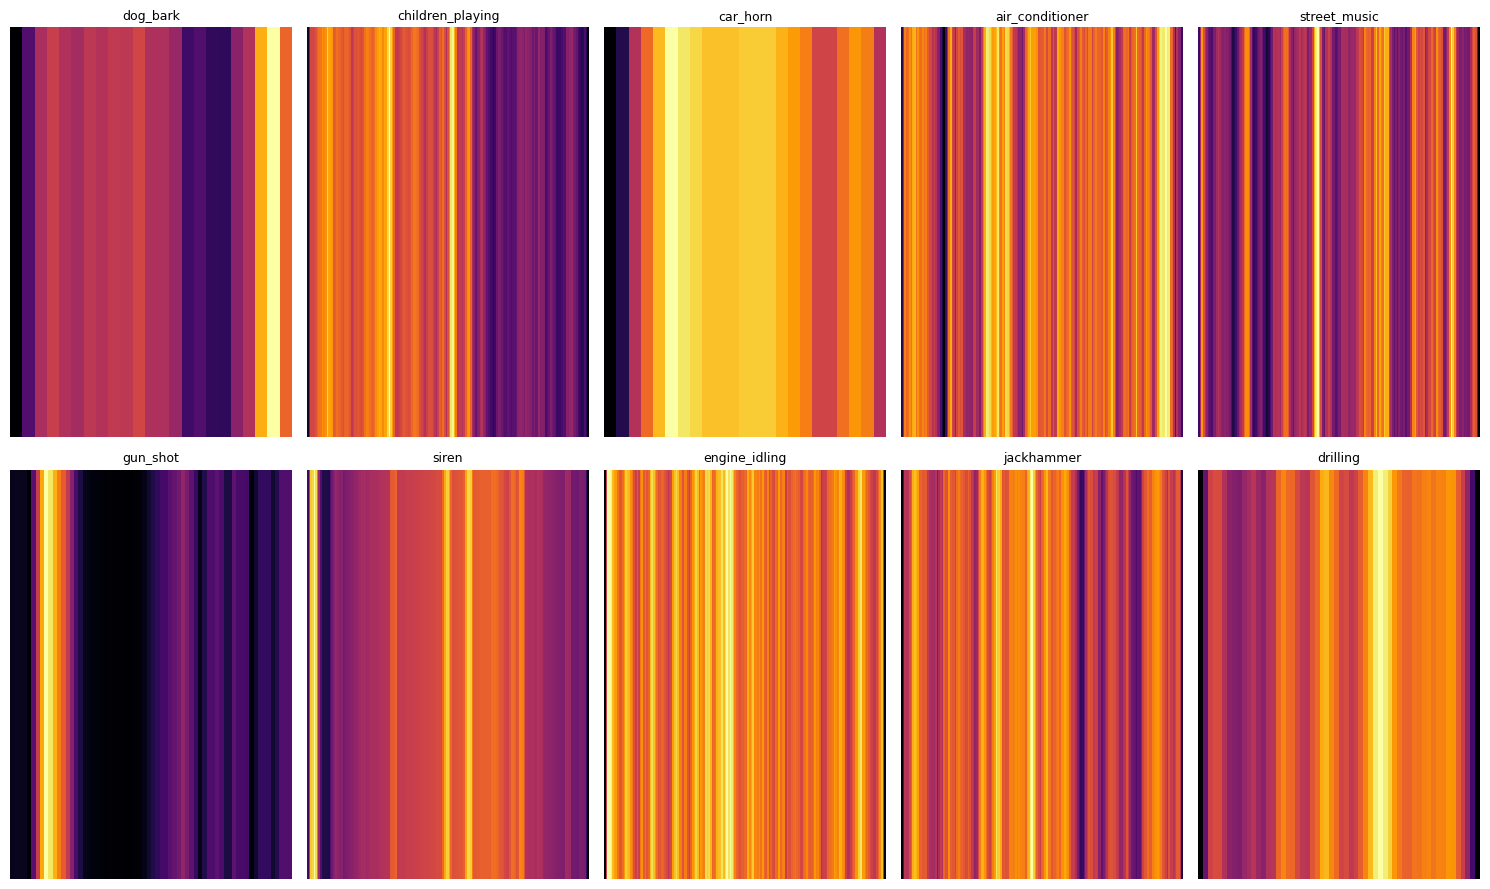

In [15]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Output directory for ZCR plots
output_dir = "/kaggle/working/zcr_plots"
os.makedirs(output_dir, exist_ok=True)

# Unique sound classes
unique_classes = metadata['class'].unique()

# Grid layout setup for thumbnails
n_classes = len(unique_classes)
cols = 5
rows = int(np.ceil(n_classes / cols))
plt.figure(figsize=(15, 9))

for i, sound_class in enumerate(unique_classes):
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)

    if not file_path:
        continue

    y, sr = librosa.load(file_path, sr=22050)
    zcr = librosa.feature.zero_crossing_rate(y)

    # For thumbnail: simulate 2D
    zcr_img = np.repeat(zcr, repeats=12, axis=0)

    # Plot thumbnail
    plt.subplot(rows, cols, i + 1)
    librosa.display.specshow(zcr_img, x_axis='time', cmap='inferno')
    plt.title(sound_class, fontsize=9)
    plt.axis('off')

    # Save detailed image
    fig, ax = plt.subplots(figsize=(4, 2))
    img = librosa.display.specshow(zcr_img, x_axis='time', cmap='inferno', ax=ax)
    plt.title(f'Zero-Crossing Rate of {sound_class}', fontsize=9)
    plt.ylabel("Simulated ZCR")
    plt.colorbar(img, ax=ax)
    fig.savefig(f"/kaggle/working/zcr_plots/{sound_class}_zcr.png", bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)


plt.tight_layout()
plt.show()


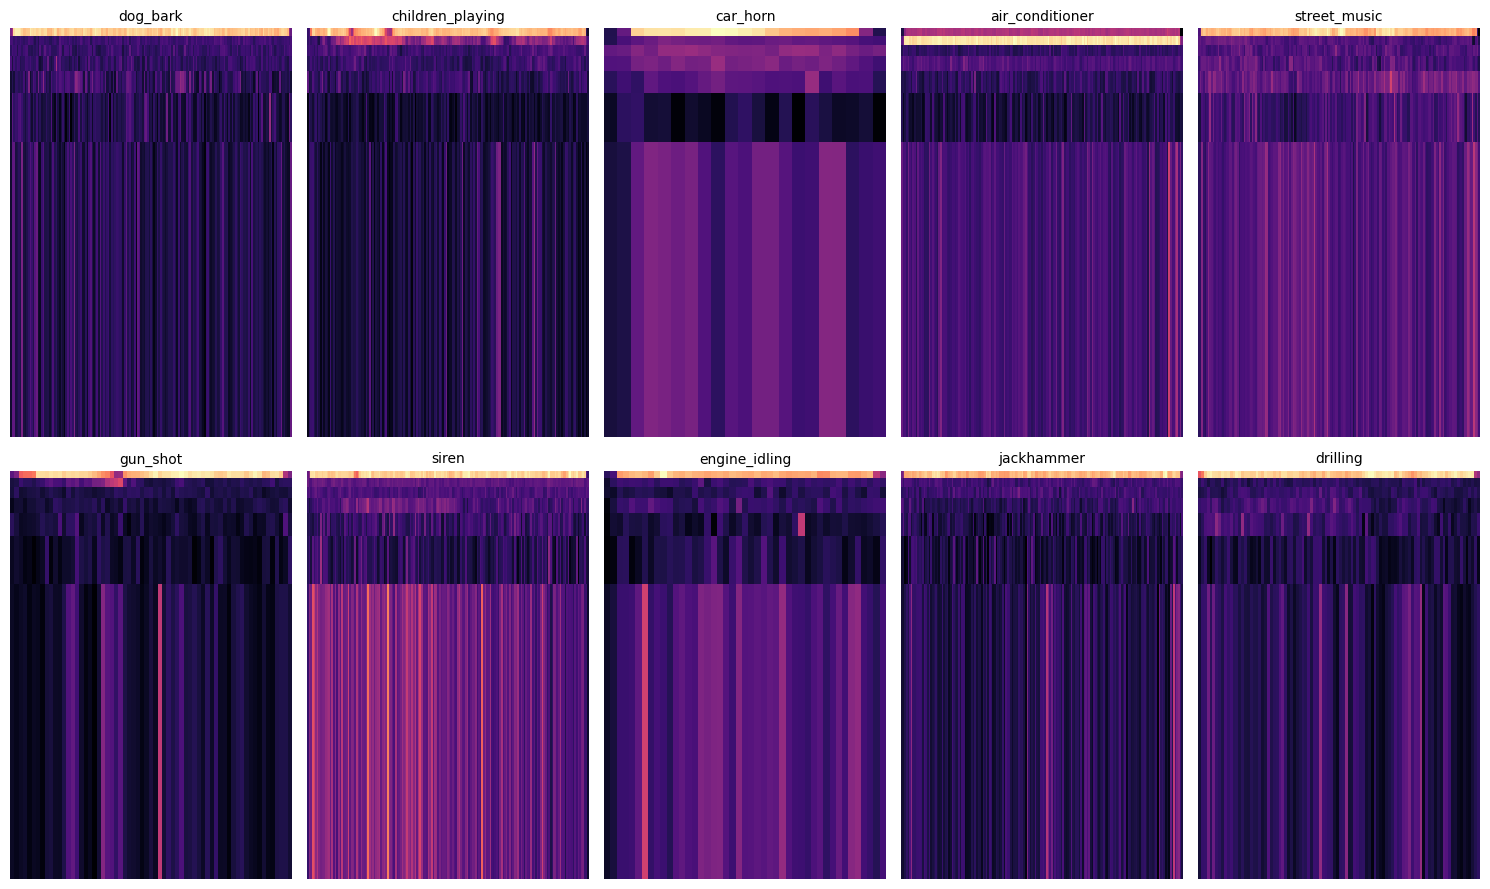

In [16]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Output directory
output_dir = "/kaggle/working/spectral_contrast_plots"
os.makedirs(output_dir, exist_ok=True)

# Unique sound classes
unique_classes = metadata['class'].unique()

# Set up grid layout
n_classes = len(unique_classes)
cols = 5
rows = int(np.ceil(n_classes / cols))
plt.figure(figsize=(15, 9))

for i, sound_class in enumerate(unique_classes):
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)

    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    # Load audio
    y, sr = librosa.load(file_path, sr=22050)

    # Compute spectral contrast
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

    # Show in grid
    plt.subplot(rows, cols, i + 1)
    librosa.display.specshow(contrast, x_axis='time', y_axis='log', cmap='magma')
    plt.title(sound_class, fontsize=10)
    plt.axis('off')

    # Save individual plot
    fig, ax = plt.subplots(figsize=(4, 2))
    img = librosa.display.specshow(contrast, x_axis='time', cmap='magma', ax=ax)
    plt.title(f'Spectral Contrast of {sound_class}', fontsize=9)
    plt.ylabel("Frequency Bands")
    plt.colorbar(img, ax=ax)
    plt.tight_layout()
    save_path = os.path.join(output_dir, f"{sound_class}_spectral_contrast.png")
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)

plt.tight_layout()
plt.show()


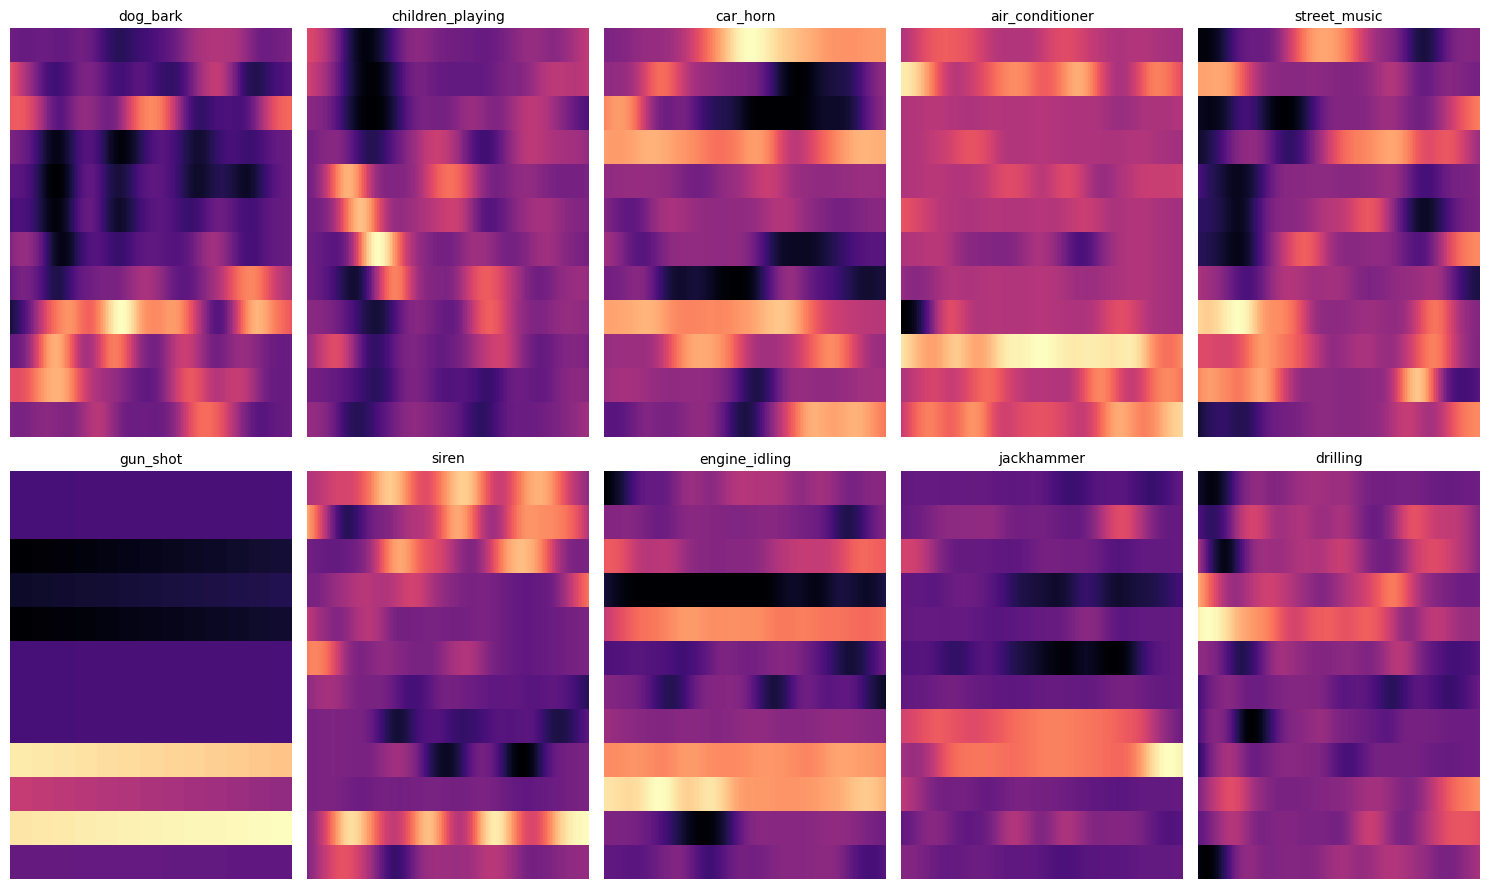

In [17]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output directory
output_dir = "/kaggle/working/chroma_cens_plots"
os.makedirs(output_dir, exist_ok=True)

# Unique classes from metadata
unique_classes = metadata['class'].unique()

# Set up plot grid
n_classes = len(unique_classes)
cols = 5
rows = int(np.ceil(n_classes / cols))
plt.figure(figsize=(15, 9))  # Adjust size as needed

for i, sound_class in enumerate(unique_classes):
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)

    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    # Load audio
    y, sr = librosa.load(file_path, sr=22050)

    # Compute Chroma CENS
    chroma_cens = librosa.feature.chroma_cens(y=y, sr=sr)

    # Show in grid
    plt.subplot(rows, cols, i + 1)
    librosa.display.specshow(chroma_cens, x_axis='time', y_axis='chroma', cmap='magma')
    plt.title(sound_class, fontsize=10)
    plt.axis('off')

    # Save individual image
    fig, ax = plt.subplots(figsize=(4, 2))
    img = librosa.display.specshow(chroma_cens, x_axis='time', y_axis='chroma', cmap='magma', ax=ax)
    plt.title(f'Chroma Cens of {sound_class}', fontsize=9)
    plt.colorbar(img, ax=ax)
    plt.tight_layout()
    save_path = os.path.join(output_dir, f"{sound_class}_chroma_cens.png")
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)

plt.tight_layout()
plt.show()


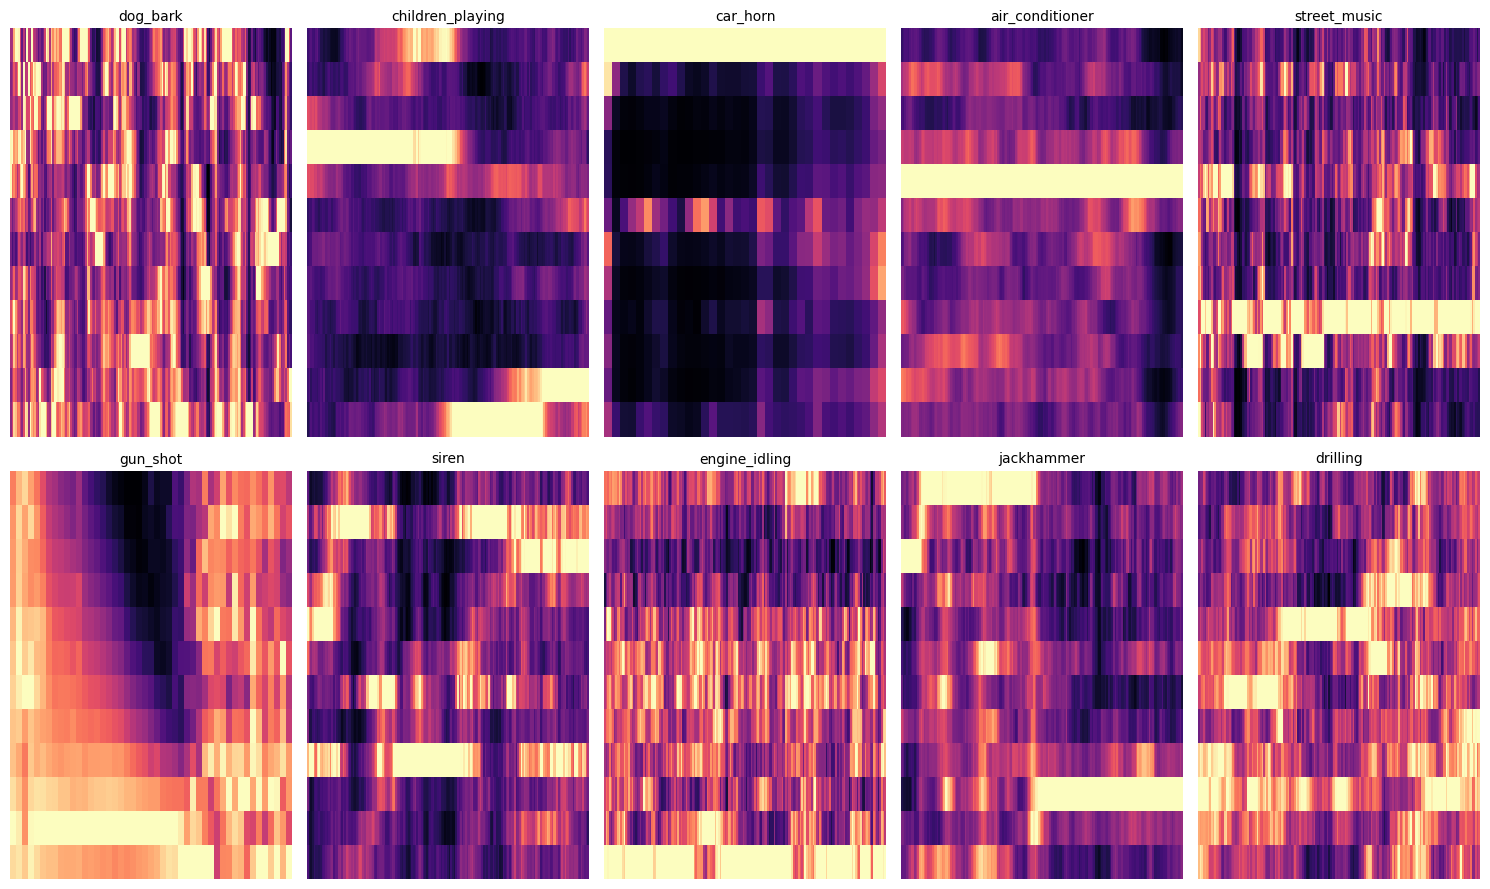

In [18]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output directory
output_dir = "/kaggle/working/chroma_cqt_plots"
os.makedirs(output_dir, exist_ok=True)

# Unique classes from metadata
unique_classes = metadata['class'].unique()

# Set up plot grid
n_classes = len(unique_classes)
cols = 5
rows = int(np.ceil(n_classes / cols))
plt.figure(figsize=(15, 9))  # Adjust size as needed

for i, sound_class in enumerate(unique_classes):
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)

    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    # Load audio
    y, sr = librosa.load(file_path, sr=22050)

    # Compute Chroma CQT
    chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr)

    # Show in grid
    plt.subplot(rows, cols, i + 1)
    librosa.display.specshow(chroma_cqt, x_axis='time', y_axis='chroma', cmap='magma')
    plt.title(sound_class, fontsize=10)
    plt.axis('off')

    # Save individual image
    fig, ax = plt.subplots(figsize=(4, 2))
    img = librosa.display.specshow(chroma_cqt, x_axis='time', y_axis='chroma', cmap='magma', ax=ax)
    plt.title(f'Chroma CQT of {sound_class}', fontsize=9)
    plt.colorbar(img, ax=ax)
    plt.tight_layout()
    save_path = os.path.join(output_dir, f"{sound_class}_chroma_cqt.png")
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)

plt.tight_layout()
plt.show()


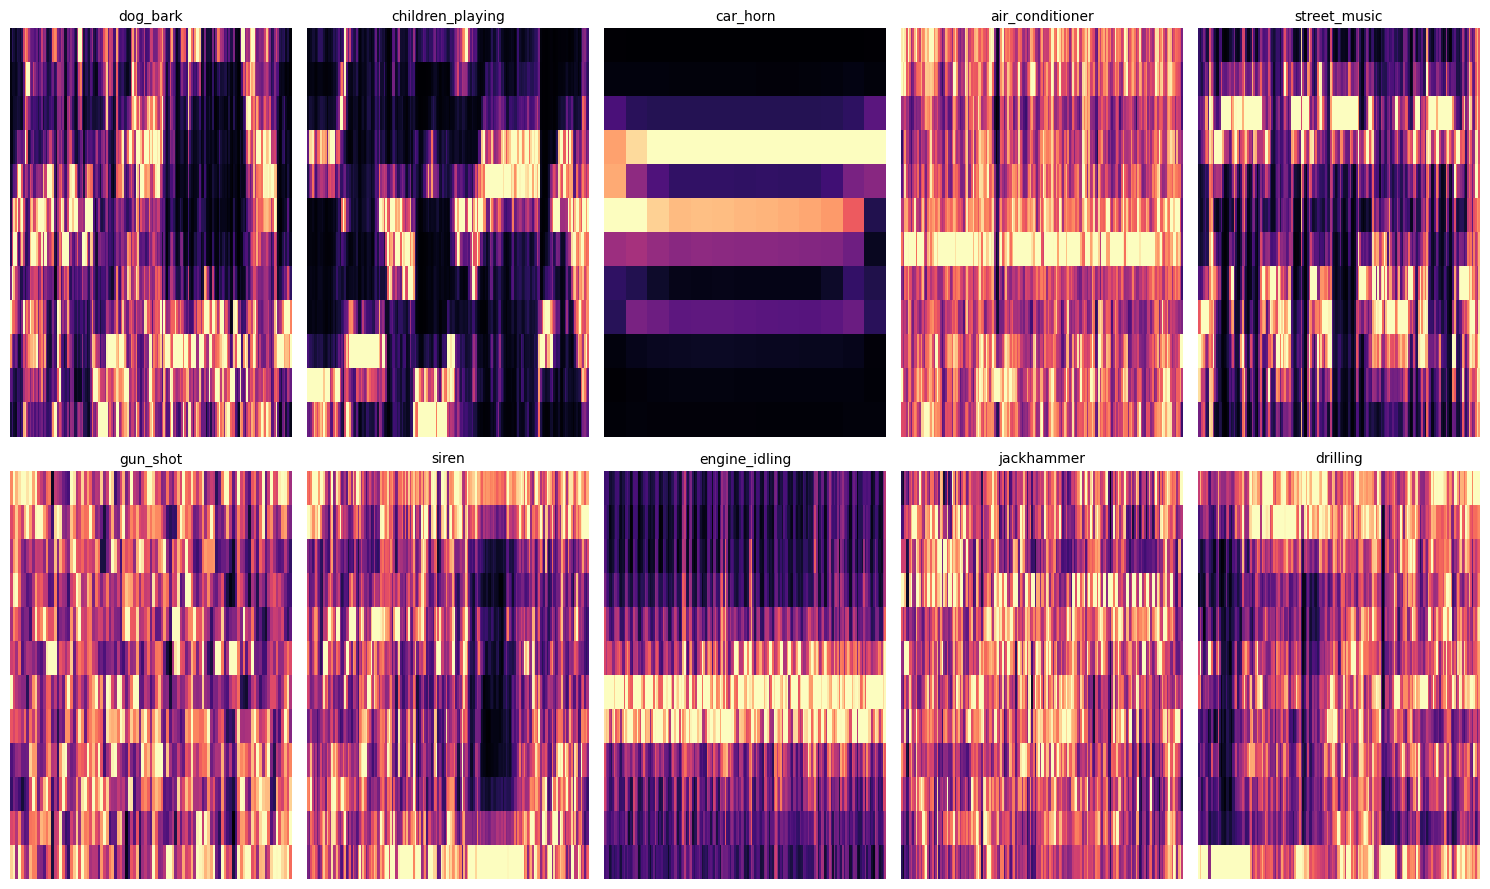

In [19]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output directory if it doesn't exist
output_dir = "/kaggle/working/chroma_plots"
os.makedirs(output_dir, exist_ok=True)

# Unique classes from metadata
unique_classes = metadata['class'].unique()

# Set up plot grid
n_classes = len(unique_classes)
cols = 5
rows = int(np.ceil(n_classes / cols))
plt.figure(figsize=(15, 9))  # Adjust based on number of classes

for i, sound_class in enumerate(unique_classes):
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)

    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    # Load audio
    y, sr = librosa.load(file_path, sr=22050)

    # Compute Chroma STFT
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12, n_fft=2048)

    # Show in grid
    plt.subplot(rows, cols, i + 1)
    librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='magma')
    plt.title(sound_class, fontsize=10)
    plt.axis('off')

    # Save individual image
    fig, ax = plt.subplots(figsize=(4, 2))
    img = librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='magma', ax=ax)
    plt.title(f'Chroma STFT of {sound_class}', fontsize=9)
    plt.colorbar(img, ax=ax)
    plt.tight_layout()
    save_path = os.path.join(output_dir, f"{sound_class}_chroma.png")
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)

plt.tight_layout()
plt.show()


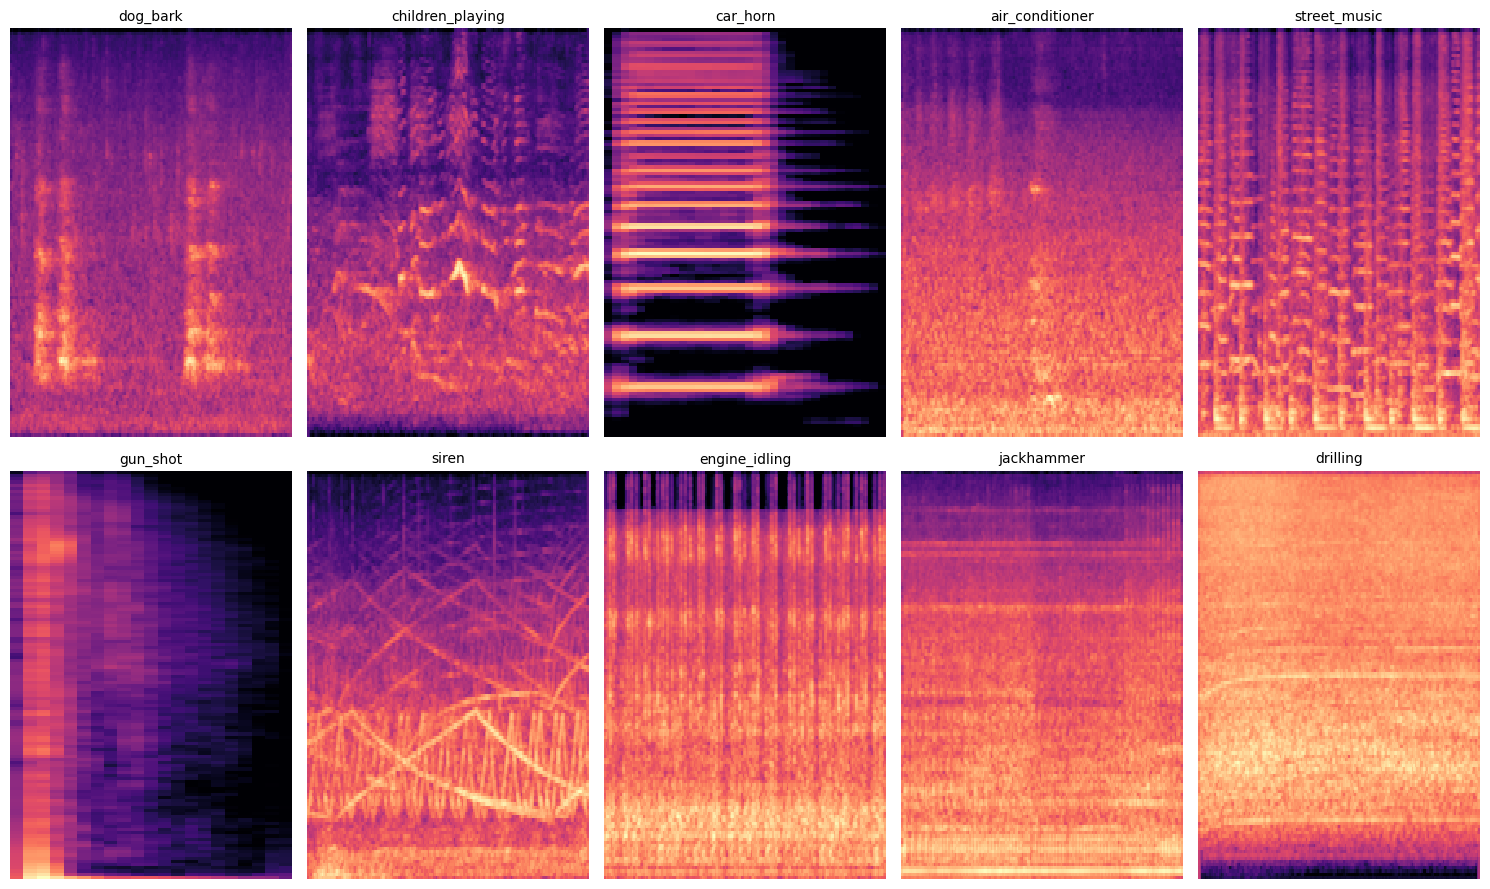

In [20]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output directory if it doesn't exist
output_dir = "/kaggle/working/spectrograms"
os.makedirs(output_dir, exist_ok=True)

# Unique classes from metadata
unique_classes = metadata['class'].unique()

# Set up plot grid (e.g., 3 rows x 5 columns if 15 classes)
n_classes = len(unique_classes)
cols = 5
rows = int(np.ceil(n_classes / cols))
plt.figure(figsize=(15, 9))  # Adjust based on how many classes you have

for i, sound_class in enumerate(unique_classes):
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)

    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    # Load audio
    audio, sr = librosa.load(file_path, sr=22050)

    # Generate mel spectrogram and convert to dB
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Plot in grid
    plt.subplot(rows, cols, i + 1)
    librosa.display.specshow(mel_db, sr=sr, cmap='magma')
    plt.axis('off')
    plt.title(sound_class, fontsize=10)

    # Save individual image
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    librosa.display.specshow(mel_db, sr=sr, cmap='magma', ax=ax)
    ax.axis('off')
    plt.tight_layout(pad=0)
    save_path = os.path.join(output_dir, f"{sound_class}.png")
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

plt.tight_layout()
plt.show()


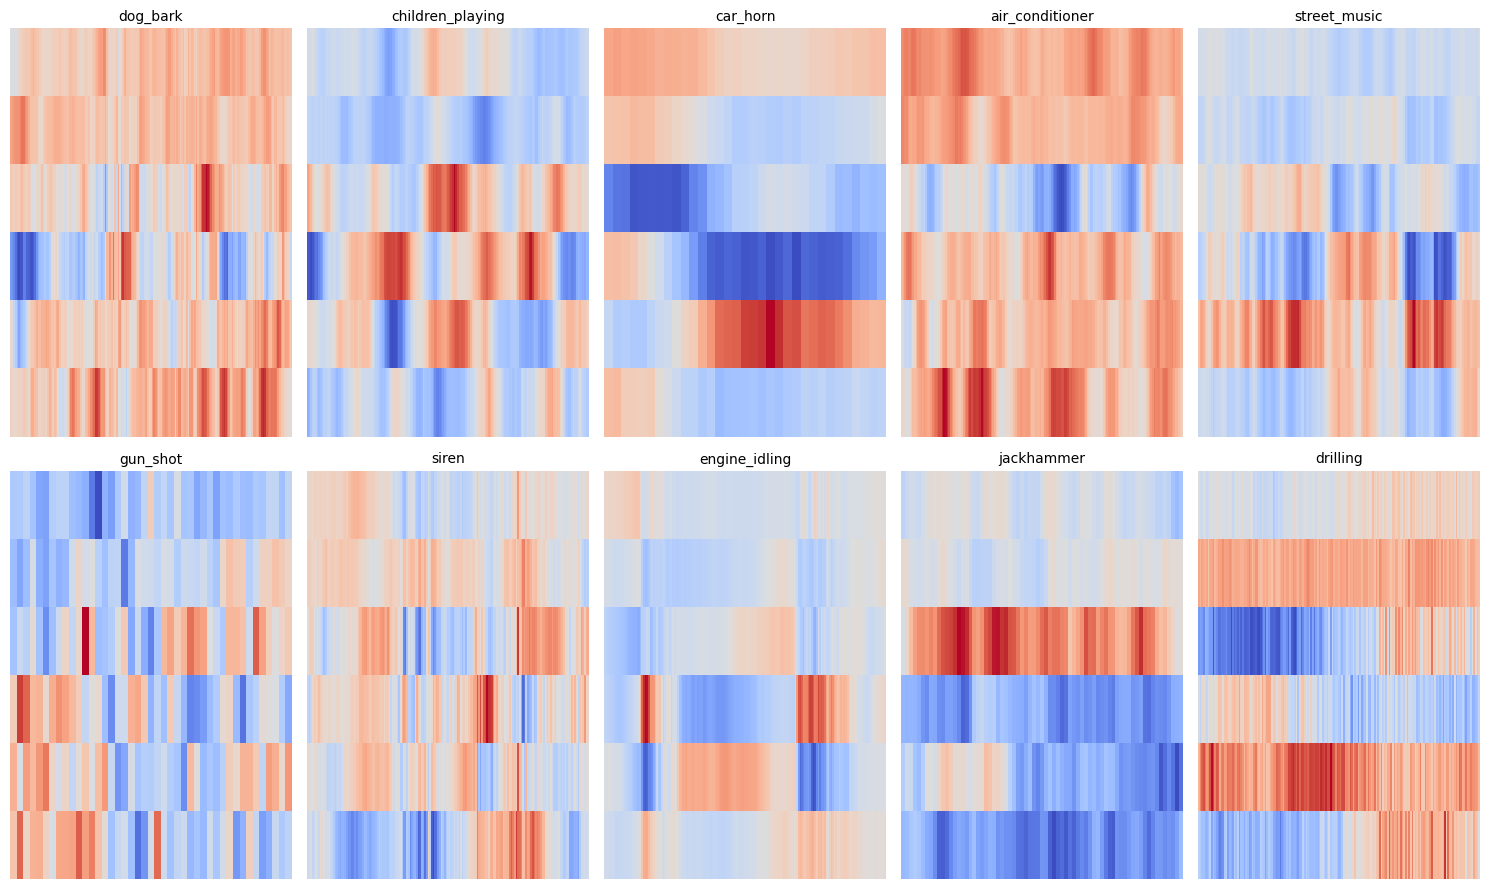

In [21]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output directory for Tonnetz
output_dir = "/kaggle/working/tonnetz"
os.makedirs(output_dir, exist_ok=True)

# Unique classes from metadata
unique_classes = metadata['class'].unique()

# Set up plot grid
n_classes = len(unique_classes)
cols = 5
rows = int(np.ceil(n_classes / cols))
plt.figure(figsize=(15, 9))

for i, sound_class in enumerate(unique_classes):
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)

    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    # Load audio
    y, sr = librosa.load(file_path, sr=22050)

    # Extract chroma features (Tonnetz needs harmonic component)
    y_harmonic, _ = librosa.effects.hpss(y)
    tonnetz = librosa.feature.tonnetz(y=y_harmonic, sr=sr)

    # Plot in grid
    plt.subplot(rows, cols, i + 1)
    librosa.display.specshow(tonnetz, x_axis='time', cmap='coolwarm')
    plt.axis('off')
    plt.title(sound_class, fontsize=10)

    # Save individual Tonnetz image
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    img = librosa.display.specshow(tonnetz, x_axis='time', cmap='coolwarm', ax=ax)
    ax.axis('off')
    plt.tight_layout(pad=0)
    save_path = os.path.join(output_dir, f"{sound_class}_tonnetz.png")
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

plt.tight_layout()
plt.show()


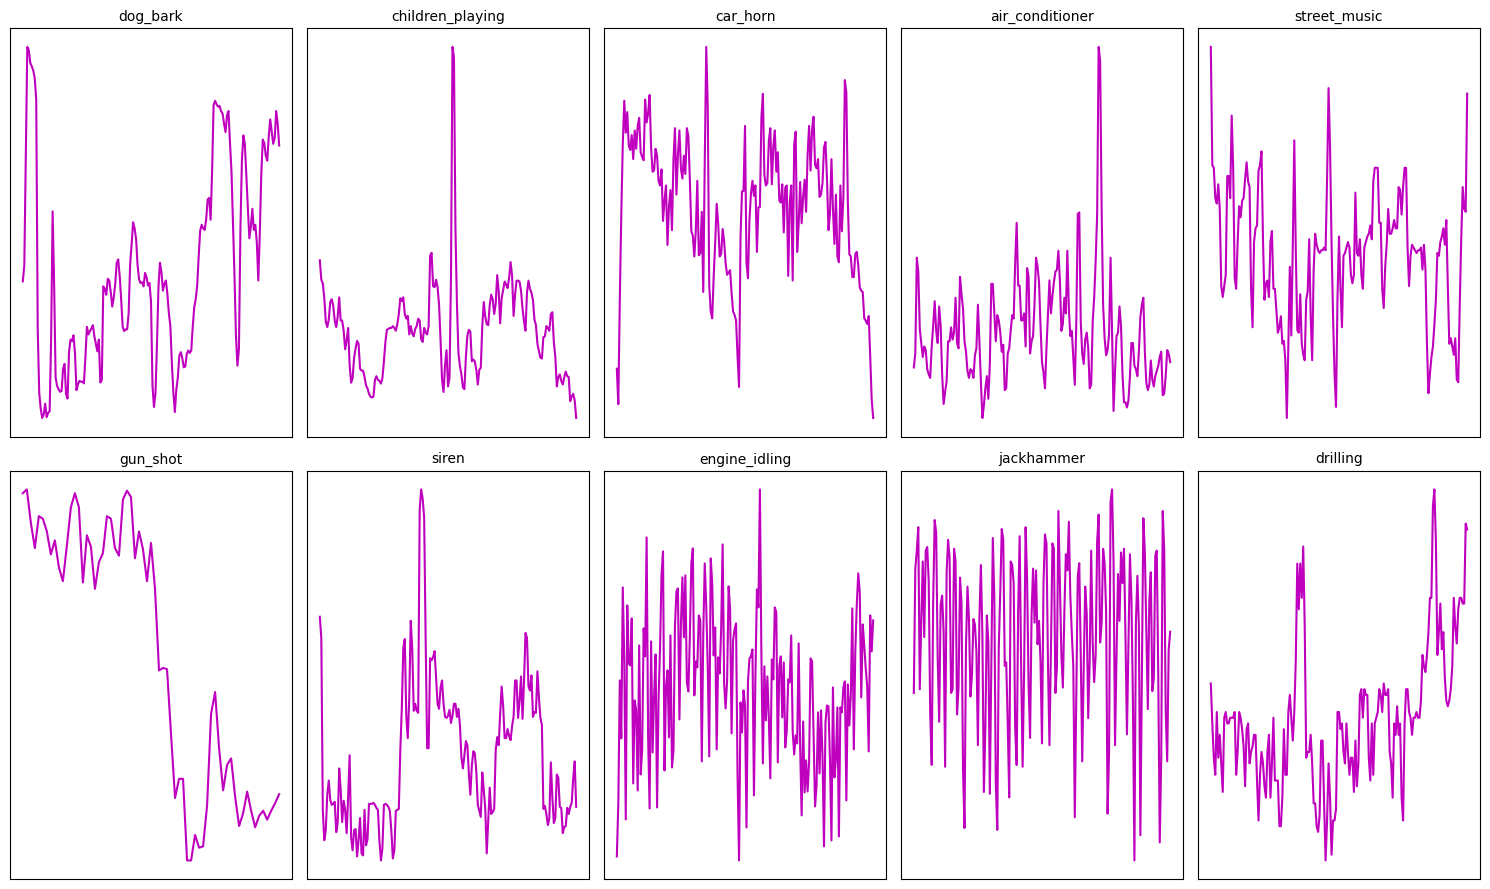

In [22]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

output_dir = "/kaggle/working/spectral_rolloff_lineplots"
os.makedirs(output_dir, exist_ok=True)

unique_classes = metadata['class'].unique()
cols = 5
rows = int(np.ceil(len(unique_classes) / cols))
plt.figure(figsize=(15, 9))

for i, sound_class in enumerate(unique_classes):
    sample_row = metadata[metadata['class'] == sound_class].sample(n=1).iloc[0]
    file_path = find_file(sample_row['slice_file_name'], DATA_PATH)

    if not file_path:
        print(f"⚠️ File not found for {sound_class}")
        continue

    y, sr = librosa.load(file_path, sr=22050)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    times = librosa.times_like(rolloff, sr=sr)

    # Plot in grid as line plot
    plt.subplot(rows, cols, i + 1)
    plt.plot(times, rolloff, color='m')
    plt.title(sound_class, fontsize=10)
    plt.xticks([])
    plt.yticks([])

    # Save individual plot
    fig, ax = plt.subplots(figsize=(3, 2))
    ax.plot(times, rolloff, color='m')
    ax.set_title(f"Spectral Rolloff: {sound_class}", fontsize=9)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Hz")
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, f"{sound_class}_rolloff_line.png"))
    plt.close(fig)

plt.tight_layout()
plt.show()
